In [1]:
# ============================================================
# Imports
# ============================================================


import os
import math
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ============================================================
# Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

c:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
def dataloader_time(DATA_PATH, FUTURE_DAYS=30):

    FEATURES = [
        "close_norm",
        "daily_return",
        "volume_norm",
        "vwap_distance",
        "volatility",
        "ma20_distance"
    ]

    TARGET = "future_return"

    df = pd.read_csv(DATA_PATH)

    print(df.head())
    print(df.columns)

    # ============================================================
    # Sort by Date
    # ============================================================

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")

    df = df.reset_index(drop=True)

    # ============================================================
    # Daily Return
    # ============================================================

    df["daily_return"] = (
        (df["Close"] - df["Prev Close"])
        / df["Prev Close"]
    )

    # ============================================================
    # MA20
    # ============================================================

    df["MA20"] = (
        df["Close"]
        .rolling(20)
        .mean()
    )

    # ============================================================
    # Rolling Volatility
    # ============================================================

    df["volatility"] = (
        df["daily_return"]
        .rolling(20)
        .std()
    )

    # ============================================================
    # VWAP Distance
    # ============================================================

    df["vwap_distance"] = (
        (df["Close"] - df["VWAP"])
        / df["VWAP"]
    )

    # ============================================================
    # MA20 Distance
    # ============================================================

    df["ma20_distance"] = (
        (df["Close"] - df["MA20"])
        / df["MA20"]
    )

    # ============================================================
    # Log Volume
    # ============================================================

    df["log_volume"] = np.log1p(df["Volume"])

    # ============================================================
    # Future N-Day Return
    # (NaN past the end, not 0 — a zero fill would inject fake
    #  flat-return labels for the last FUTURE_DAYS rows, and
    #  dropna() silently keeps them since 0 isn't NaN)
    # ============================================================

    future_return = np.full(len(df), np.nan)

    close = df["Close"].values

    for i in range(len(df) - FUTURE_DAYS):

        base = close[i]
        r = 0.0

        for j in range(1, FUTURE_DAYS + 1):
            r += (close[i + j] - base) / base

        future_return[i] = r

    df["future_return"] = future_return

    # ============================================================
    # Remove Invalid Rows
    # ============================================================

    df = df.dropna().reset_index(drop=True)

    # ============================================================
    # Normalize Close
    # ============================================================

    close_mean = df["Close"].mean()
    close_std = df["Close"].std()

    df["close_norm"] = (df["Close"] - close_mean) / (close_std + 1e-8)

    # ============================================================
    # Normalize Log Volume
    # ============================================================

    volume_mean = df["log_volume"].mean()
    volume_std = df["log_volume"].std()

    df["volume_norm"] = (df["log_volume"] - volume_mean) / (volume_std + 1e-8)

    # ============================================================
    # Keep Required Columns
    # ============================================================

    df = df[FEATURES + [TARGET]]

    print(df.head())
    print()
    print(df.shape)

    NORMALIZATION = {
        "close_mean": close_mean,
        "close_std": close_std,
        "volume_mean": volume_mean,
        "volume_std": volume_std,
    }

    return df, NORMALIZATION

In [26]:
def dataloader_mlp(DATA_PATH, FUTURE_DAYS=30):
    FEATURES = [
        # Current State
        "close_norm",
        "daily_return",
        "volume_norm",
        "vwap_distance",
        # Trend
        "momentum_15",
        "momentum_30",
        "momentum_60",
        # Risk
        "volatility_15",
        "volatility_30",
        "volatility_60",
    ]

    TARGET = "future_return"

    df = pd.read_csv(DATA_PATH)

    print(df.head())
    print(df.columns)

    # ============================================================
    # Sort by Date
    # ============================================================

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")

    df = df.reset_index(drop=True)

    # ============================================================
    # Daily Return
    # ============================================================

    df["daily_return"] = (
        (df["Close"] - df["Prev Close"])
        / df["Prev Close"]
    )

    # ============================================================
    # VWAP Distance
    # ============================================================

    df["vwap_distance"] = (
        (df["Close"] - df["VWAP"])
        / df["VWAP"]
    )

    # ============================================================
    # Momentum (multi-scale)
    # ============================================================

    for n in (15, 30, 60):
        df[f"momentum_{n}"] = (
            (df["Close"] - df["Close"].shift(n))
            / df["Close"].shift(n)
        )

    # ============================================================
    # Volatility (multi-scale)
    # ============================================================

    for n in (15, 30, 60):
        df[f"volatility_{n}"] = (
            df["daily_return"]
            .rolling(n)
            .std()
        )

    # ============================================================
    # Log Volume
    # ============================================================

    df["log_volume"] = np.log1p(df["Volume"])

    # ============================================================
    # Future N-Day Return
    # (NaN past the end, not 0 — a zero fill would inject fake
    #  flat-return labels for the last FUTURE_DAYS rows, and
    #  dropna() silently keeps them since 0 isn't NaN)
    # ============================================================

    future_return = np.full(len(df), np.nan)

    close = df["Close"].values

    for i in range(len(df) - FUTURE_DAYS):

        base = close[i]
        r = 0.0

        for j in range(1, FUTURE_DAYS + 1):
            r += (close[i + j] - base) / base

        future_return[i] = r

    df["future_return"] = future_return

    # ============================================================
    # Remove Invalid Rows
    # ============================================================

    df = df.dropna().reset_index(drop=True)

    # ============================================================
    # Normalize Close
    # ============================================================

    close_mean = df["Close"].mean()
    close_std = df["Close"].std()

    df["close_norm"] = (df["Close"] - close_mean) / (close_std + 1e-8)

    # ============================================================
    # Normalize Log Volume
    # ============================================================

    volume_mean = df["log_volume"].mean()
    volume_std = df["log_volume"].std()

    df["volume_norm"] = (df["log_volume"] - volume_mean) / (volume_std + 1e-8)

    # ============================================================
    # Keep Required Columns
    # ============================================================

    df = df[FEATURES + [TARGET]]

    print(df.head())
    print()
    print(df.shape)

    NORMALIZATION = {
        "close_mean": close_mean,
        "close_std": close_std,
        "volume_mean": volume_mean,
        "volume_std": volume_std,
    }

    return df, NORMALIZATION

In [11]:
#============================================================
# LSTM Return Predictor
# ============================================================

class LSTMReturnPredictor(nn.Module):

    def __init__(
        self,
        input_size=6,
        hidden_size=128,
        num_layers=4,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 64)

        self.gelu = nn.GELU()

        self.dropout = nn.Dropout(dropout)

        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        x = hidden[-1]

        x = self.fc1(x)

        x = self.gelu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x


In [10]:
class GRUReturnPredictor(nn.Module):

    def __init__(
        self,
        input_size=6,
        hidden_size=128,
        num_layers=4,
        dropout=0.3
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 64)

        self.gelu = nn.GELU()

        self.dropout = nn.Dropout(dropout)

        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):

        output, hidden = self.gru(x)

        x = hidden[-1]

        x = self.fc1(x)

        x = self.gelu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x


In [9]:

class CNNReturnPredictor(nn.Module):

    def __init__(
        self,
        input_size=6,
        hidden_size=128,
        num_layers=4,
        dropout=0.3
    ):
        super().__init__()

        channels = [input_size] + [hidden_size] * num_layers

        conv_blocks = []

        for i in range(num_layers):

            conv_blocks.append(
                nn.Conv1d(
                    channels[i],
                    channels[i + 1],
                    kernel_size=3,
                    padding=1
                )
            )

            # conv_blocks.append(nn.BatchNorm1d(channels[i + 1]))   # ← old line, remove/comment out
            conv_blocks.append(nn.GroupNorm(num_groups=8, num_channels=channels[i + 1]))   # ← new line

            conv_blocks.append(nn.GELU())

            conv_blocks.append(nn.Dropout(dropout))

        self.conv = nn.Sequential(*conv_blocks)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(hidden_size, 64)

        self.gelu = nn.GELU()

        self.dropout = nn.Dropout(dropout)

        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.conv(x)

        x = self.pool(x).squeeze(-1)

        x = self.fc1(x)

        x = self.gelu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [8]:
# ============================================================
# MLP Agent
# Per project convention: MLP agents consume the mean of the
# lookback window rather than the raw sequence (unlike the
# LSTM/GRU/CNN agents), so input to the network is a single
# 10-dim vector per sample.
# ============================================================

class MLPReturnPredictor(nn.Module):

    def __init__(
        self,
        input_size=10,
        hidden_size=64,
        dropout=0.4
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        # x: (batch, lookback, features) -> mean over time -> (batch, features)
        x = x.mean(dim=1)
        return self.net(x)


In [7]:

# ============================================================
# Correlation Loss
# ============================================================

def correlation_loss(pred, target):

    pred = pred.squeeze()
    target = target.squeeze()

    pred = pred - pred.mean()
    target = target - target.mean()

    corr = torch.sum(pred * target)

    corr = corr / (
        torch.sqrt(torch.sum(pred ** 2))
        * torch.sqrt(torch.sum(target ** 2))
        + 1e-8
    )

    return 1.0 - corr


# ============================================================
# Direction Loss
# ============================================================

def direction_loss(pred, target):

    pred = pred.squeeze()
    target = target.squeeze()

    pred = F.normalize(pred.unsqueeze(0), dim=1)
    target = F.normalize(target.unsqueeze(0), dim=1)

    return 1.0 - F.cosine_similarity(
        pred,
        target
    ).mean()


# ============================================================
# Standard Deviation Matching Loss
# ============================================================

def std_loss(pred, target):

    return (
        torch.std(pred) - torch.std(target)
    ) ** 2


# ============================================================
# Lag-1 Autocorrelation
# ============================================================

def autocorr_lag1(x):

    x = x.squeeze()

    var = torch.var(x)

    if var < 1e-8:
        return torch.tensor(0.0, device=x.device)

    xc = x - torch.mean(x)

    return torch.mean(
        xc[:-1] * xc[1:]
    ) / (var + 1e-8)


# ============================================================
# Autocorrelation Loss
# ============================================================

def autocorr_loss(pred, target):

    return (
        autocorr_lag1(pred)
        -
        autocorr_lag1(target)
    ) ** 2


agent_loss={
    "lstm":{"h":5.0,"c":1.0,"s":0.5,"a":0.5},
    "gru":{"h":5.0,"c":1.0,"s":0.5,"a":0.5},
    "cnn":{"h":5.0,"c":1.0,"s":0.5,"a":0.5},
    "mlp":{"h":5.0,"c":1.0,"s":0.5,"a":0.5}
}



# ============================================================
# Final Loss
# ============================================================

def total_loss(pred, target, agent_type="lstm"):

    huber = F.smooth_l1_loss(pred, target)

    # mse = F.mse_loss(pred, target)

    corr = correlation_loss(pred, target)

    # direction = direction_loss(pred, target)

    std = std_loss(pred, target)

    auto = autocorr_loss(pred, target)

    loss = (
        agent_loss[agent_type]["h"] * huber + 
        agent_loss[agent_type]["c"] * corr + 
        agent_loss[agent_type]["s"] * std +
        agent_loss[agent_type]["a"] * auto
    )

    return loss


In [6]:
def Metrics(true,pred):
    
    # ============================================================
    # Metrics
    # ============================================================

    mae = np.mean(
        np.abs(pred - true)
    )

    rmse = np.sqrt(
        np.mean(
            (pred - true)**2
        )
    )

    corr = np.corrcoef(
        pred,
        true
    )[0,1]

    direction_acc = np.mean(
        np.sign(pred)==np.sign(true)
    )

    print()

    print(f"MAE               : {mae:.6f}")
    print(f"RMSE              : {rmse:.6f}")
    print(f"Correlation       : {corr:.4f}")
    print(f"Direction Accuracy: {direction_acc:.4f}")


def loss_plot(train_losses, val_losses):
        
    plt.figure(figsize=(10,5))

    plt.plot(train_losses,label="Train")
    plt.plot(val_losses,label="Validation")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.show()


In [5]:
def test_plot(true, pred, sens=2.0, agent_type="agent", Future_day=30):
    # ============================================================
    # Plot Actual vs Predicted Returns
    # ============================================================

    plt.figure(figsize=(16, 7))

    x = np.arange(len(true))

    plt.plot(
        x,
        true,
        color="black",
        linewidth=1.5,
        label="Actual"
    )

    plt.plot(
        x,
        pred*sens,
        color="tab:blue",
        linewidth=2,
        label=agent_type
    )

    plt.title(f"{Future_day}-Day Future Return Prediction", fontsize=16)

    plt.xlabel("Day", fontsize=12)

    plt.ylabel(f"{Future_day}-Day Cumulative Return", fontsize=12)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [20]:
def train_lstm(DATA_PATH, MODEL_PATH ,f_days=30):


    # ============================================================
    # Hyperparameters
    # ============================================================

    LOOKBACK = 120
    FUTURE_DAYS = f_days
    HIDDEN_SIZE = 128
    NUM_LAYERS = 4
    DROPOUT = 0.3
    LR = 1e-3
    WEIGHT_DECAY = 1e-4

    NUM_EPOCHS = 75

    TRAIN_RATIO = 0.8
    
    FEATURES = [
        "close_norm",
        "daily_return",
        "volume_norm",
        "vwap_distance",
        "volatility",
        "ma20_distance"
    ]

    TARGET = "future_return"

    
    df,norm = dataloader_time(DATA_PATH, FUTURE_DAYS)

    
    X = []
    Y = []

    feature_data = df[FEATURES].values.astype(np.float32)
    target_data = df[TARGET].values.astype(np.float32)

    for i in range(len(df) - LOOKBACK):

        X.append(
            feature_data[i:i + LOOKBACK]
        )

        Y.append(
            target_data[i + LOOKBACK - 1]
        )

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

    print("Feature Shape :", X.shape)
    print("Target Shape  :", Y.shape)


    # ============================================================
    # Train / Validation Split
    # ============================================================

    split = int(len(X) * TRAIN_RATIO)

    X_train = X[:split]
    Y_train = Y[:split]

    X_val = X[split:]
    Y_val = Y[split:]

    print()
    print("Train Samples      :", len(X_train))
    print("Validation Samples :", len(X_val))
    
    # ============================================================
    # Normalize Target (Training Statistics Only)
    # ============================================================

    target_mean = Y_train.mean()
    target_std = Y_train.std()

    Y_train = (Y_train - target_mean) / (target_std + 1e-8)
    Y_val = (Y_val - target_mean) / (target_std + 1e-8)

    print()
    print("Target Mean :", target_mean)
    print("Target Std  :", target_std)


    # ============================================================
    # Convert To Torch
    # ============================================================

    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32)

    print()
    print("Training Tensor   :", X_train.shape)
    print("Validation Tensor :", X_val.shape)

    
    model = LSTMReturnPredictor(
        input_size=len(FEATURES),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    print(model)

    # ============================================================
    # Optimizer
    # ============================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    print("Optimizer Ready")

    ######

    # ============================================================
    # Training
    # ============================================================

    train_losses = []
    val_losses = []

    best_loss = float("inf")

    for epoch in range(NUM_EPOCHS):

        ##########################
        # Train
        ##########################

        model.train()

        optimizer.zero_grad()

        pred = model(X_train)

        loss = total_loss(pred, Y_train, "lstm")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        ##########################
        # Validation
        ##########################

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = total_loss(
                val_pred,
                Y_val
            )

        ##########################
        # Save
        ##########################

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss.item() < best_loss:

            best_loss = val_loss.item()

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "normalization": norm,   # or norm, for lstm/gru/cnn
                },
                MODEL_PATH,
            )

        ##########################
        # Print
        ##########################

        print(
            f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
            f"Train {loss.item():.5f} | "
            f"Val {val_loss.item():.5f}"
        )

    print()

    print("Training Finished")

    # model.load_state_dict(
    #     torch.load(
    #         MODEL_PATH
    #     )
    # )
    ckpt = torch.load(MODEL_PATH)
    model.load_state_dict(ckpt["model_state_dict"])
    normalization = ckpt["normalization"]

    model.eval()

    
    # ============================================================
    # Prediction
    # ============================================================

    with torch.no_grad():

        pred = model(X_val)

    pred = pred.cpu().numpy().flatten()

    true = Y_val.cpu().numpy().flatten()

    Metrics(true, pred)

    loss_plot(train_losses,val_losses)

    test_plot(true,pred,2.0,"lstm",30)


In [21]:
def train_gru(DATA_PATH, MODEL_PATH ,f_days=30):


    # ============================================================
    # Hyperparameters
    # ============================================================

    LOOKBACK = 60
    FUTURE_DAYS = f_days
    HIDDEN_SIZE = 128
    NUM_LAYERS = 4
    DROPOUT = 0.3
    LR = 1e-3
    WEIGHT_DECAY = 1e-4

    NUM_EPOCHS = 75

    TRAIN_RATIO = 0.8
    
    FEATURES = [
        "close_norm",
        "daily_return",
        "volume_norm",
        "vwap_distance",
        "volatility",
        "ma20_distance"
    ]

    TARGET = "future_return"

    
    df,norm = dataloader_time(DATA_PATH, FUTURE_DAYS)

    
    X = []
    Y = []

    feature_data = df[FEATURES].values.astype(np.float32)
    target_data = df[TARGET].values.astype(np.float32)

    for i in range(len(df) - LOOKBACK):

        X.append(
            feature_data[i:i + LOOKBACK]
        )

        Y.append(
            target_data[i + LOOKBACK - 1]
        )

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

    print("Feature Shape :", X.shape)
    print("Target Shape  :", Y.shape)


    # ============================================================
    # Train / Validation Split
    # ============================================================

    split = int(len(X) * TRAIN_RATIO)

    X_train = X[:split]
    Y_train = Y[:split]

    X_val = X[split:]
    Y_val = Y[split:]

    print()
    print("Train Samples      :", len(X_train))
    print("Validation Samples :", len(X_val))
    
    # ============================================================
    # Normalize Target (Training Statistics Only)
    # ============================================================

    target_mean = Y_train.mean()
    target_std = Y_train.std()

    Y_train = (Y_train - target_mean) / (target_std + 1e-8)
    Y_val = (Y_val - target_mean) / (target_std + 1e-8)

    print()
    print("Target Mean :", target_mean)
    print("Target Std  :", target_std)


    # ============================================================
    # Convert To Torch
    # ============================================================

    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32)

    print()
    print("Training Tensor   :", X_train.shape)
    print("Validation Tensor :", X_val.shape)

    
    model = GRUReturnPredictor(
        input_size=len(FEATURES),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    print(model)

    # ============================================================
    # Optimizer
    # ============================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    print("Optimizer Ready")

    ######

    # ============================================================
    # Training
    # ============================================================

    train_losses = []
    val_losses = []

    best_loss = float("inf")

    for epoch in range(NUM_EPOCHS):

        ##########################
        # Train
        ##########################

        model.train()

        optimizer.zero_grad()

        pred = model(X_train)

        loss = total_loss(pred, Y_train)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        ##########################
        # Validation
        ##########################

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = total_loss(
                val_pred,
                Y_val, 
                "gru"
            )

        ##########################
        # Save
        ##########################

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss.item() < best_loss:

            best_loss = val_loss.item()

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "normalization": norm,   # or norm, for lstm/gru/cnn
                },
                MODEL_PATH,
            )

        ##########################
        # Print
        ##########################

        print(
            f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
            f"Train {loss.item():.5f} | "
            f"Val {val_loss.item():.5f}"
        )

    print()

    print("Training Finished")

    # model.load_state_dict(
    #     torch.load(
    #         MODEL_PATH
    #     )
    # )
    ckpt = torch.load(MODEL_PATH)
    model.load_state_dict(ckpt["model_state_dict"])
    normalization = ckpt["normalization"]

    model.eval()

    
    # ============================================================
    # Prediction
    # ============================================================

    with torch.no_grad():

        pred = model(X_val)

    pred = pred.cpu().numpy().flatten()

    true = Y_val.cpu().numpy().flatten()

    Metrics(true, pred)

    loss_plot(train_losses,val_losses)

    test_plot(true,pred,3.0,"gru")


In [22]:
def train_cnn(DATA_PATH, MODEL_PATH , f_days=30):


    # ============================================================
    # Hyperparameters
    # ============================================================

    LOOKBACK = 30
    FUTURE_DAYS = f_days
    HIDDEN_SIZE = 64
    NUM_LAYERS = 2
    DROPOUT = 0.5
    LR = 1e-3
    WEIGHT_DECAY = 1e-3

    NUM_EPOCHS = 50

    TRAIN_RATIO = 0.8
    
    FEATURES = [
        "close_norm",
        "daily_return",
        "volume_norm",
        "vwap_distance",
        "volatility",
        "ma20_distance"
    ]

    TARGET = "future_return"

    
    df,norm = dataloader_time(DATA_PATH, FUTURE_DAYS)

    
    X = []
    Y = []

    feature_data = df[FEATURES].values.astype(np.float32)
    target_data = df[TARGET].values.astype(np.float32)

    for i in range(len(df) - LOOKBACK):

        X.append(
            feature_data[i:i + LOOKBACK]
        )

        Y.append(
            target_data[i + LOOKBACK - 1]
        )

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

    print("Feature Shape :", X.shape)
    print("Target Shape  :", Y.shape)


    # ============================================================
    # Train / Validation Split
    # ============================================================

    split = int(len(X) * TRAIN_RATIO)

    X_train = X[:split]
    Y_train = Y[:split]

    X_val = X[split:]
    Y_val = Y[split:]

    print()
    print("Train Samples      :", len(X_train))
    print("Validation Samples :", len(X_val))
    
    # ============================================================
    # Normalize Target (Training Statistics Only)
    # ============================================================

    target_mean = Y_train.mean()
    target_std = Y_train.std()

    Y_train = (Y_train - target_mean) / (target_std + 1e-8)
    Y_val = (Y_val - target_mean) / (target_std + 1e-8)

    print()
    print("Target Mean :", target_mean)
    print("Target Std  :", target_std)


    # ============================================================
    # Convert To Torch
    # ============================================================

    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32)

    print()
    print("Training Tensor   :", X_train.shape)
    print("Validation Tensor :", X_val.shape)

    
    model = CNNReturnPredictor(
        input_size=len(FEATURES),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    )

    print(model)

    # ============================================================
    # Optimizer
    # ============================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    print("Optimizer Ready")

    ######

    # ============================================================
    # Training
    # ============================================================

    train_losses = []
    val_losses = []

    best_loss = float("inf")

    for epoch in range(NUM_EPOCHS):

        ##########################
        # Train
        ##########################

        model.train()

        optimizer.zero_grad()

        pred = model(X_train)

        loss = total_loss(pred, Y_train, "cnn")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        ##########################
        # Validation
        ##########################

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = total_loss(
                val_pred,
                Y_val
            )

        ##########################
        # Save
        ##########################

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss.item() < best_loss:

            best_loss = val_loss.item()

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "normalization": norm,   # or norm, for lstm/gru/cnn
                },
                MODEL_PATH,
            )
        ##########################
        # Print
        ##########################

        print(
            f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
            f"Train {loss.item():.5f} | "
            f"Val {val_loss.item():.5f}"
        )

    print()

    print("Training Finished")

    # model.load_state_dict(
    #     torch.load(
    #         MODEL_PATH
    #     )
    # )
    ckpt = torch.load(MODEL_PATH)
    model.load_state_dict(ckpt["model_state_dict"])
    normalization = ckpt["normalization"]

    model.eval()

    
    # ============================================================
    # Prediction
    # ============================================================

    with torch.no_grad():

        pred = model(X_val)

    pred = pred.cpu().numpy().flatten()

    true = Y_val.cpu().numpy().flatten()

    Metrics(true, pred)

    loss_plot(train_losses,val_losses)

    test_plot(true,pred,4.0,"cnn", 15)


In [23]:
def train_mlp(DATA_PATH, MODEL_PATH , f_days=30):
    # ============================================================
    # Hyperparameters
    # ============================================================

    LOOKBACK = 60

    FUTURE_DAYS = f_days          # change to 15 as needed

    HIDDEN_SIZE = 64

    DROPOUT = 0.4

    LR = 1e-3

    WEIGHT_DECAY = 1e-3

    NUM_EPOCHS = 150

    EARLY_STOP_PATIENCE = 15

    TRAIN_RATIO = 0.8

    # purge gap so no val window shares data with any train window
    # (windows slide by 1 day, so anything within LOOKBACK+FUTURE_DAYS
    # of the split boundary overlaps across the split)
    PURGE = LOOKBACK + FUTURE_DAYS

    FEATURES = [
        # Current State
        "close_norm",
        "daily_return",
        "volume_norm",
        "vwap_distance",
        # Trend
        "momentum_15",
        "momentum_30",
        "momentum_60",
        # Risk
        "volatility_15",
        "volatility_30",
        "volatility_60",
    ]

    TARGET = "future_return"

    # MODEL_PATH = "best_mlp_return_model.pt"

    print("Configuration Loaded.")


    # ============================================================
    # Read Dataset
    # ============================================================

    df = pd.read_csv(DATA_PATH)

    print(df.head())
    print(df.columns)


    # ============================================================
    # Sort by Date
    # ============================================================

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")

    df = df.reset_index(drop=True)


    # ============================================================
    # Daily Return
    # ============================================================

    df["daily_return"] = (
        (df["Close"] - df["Prev Close"])
        / df["Prev Close"]
    )


    # ============================================================
    # VWAP Distance
    # ============================================================

    df["vwap_distance"] = (
        (df["Close"] - df["VWAP"])
        / df["VWAP"]
    )


    # ============================================================
    # Momentum (multi-scale)
    # momentum_N = % change vs close N days ago
    # ============================================================

    for n in (15, 30, 60):
        df[f"momentum_{n}"] = (
            (df["Close"] - df["Close"].shift(n))
            / df["Close"].shift(n)
        )


    # ============================================================
    # Volatility (multi-scale)
    # rolling std of daily_return over N days
    # ============================================================

    for n in (15, 30, 60):
        df[f"volatility_{n}"] = (
            df["daily_return"]
            .rolling(n)
            .std()
        )


    # ============================================================
    # Log Volume
    # ============================================================

    df["log_volume"] = np.log1p(df["Volume"])


    # ============================================================
    # Future N-Day Return (NaN past the end, not 0 — avoids
    # injecting fake flat-return labels into training)
    # ============================================================

    future_return = np.full(len(df), np.nan)

    close = df["Close"].values

    for i in range(len(df) - FUTURE_DAYS):

        base = close[i]
        r = 0.0

        for j in range(1, FUTURE_DAYS + 1):
            r += (close[i + j] - base) / base

        future_return[i] = r

    df["future_return"] = future_return


    # ============================================================
    # Remove Invalid Rows
    # ============================================================

    df = df.dropna().reset_index(drop=True)


    # ============================================================
    # Normalize Close / Log Volume
    # (momentum & volatility are already scale-free ratios/stds,
    #  left unscaled here; z-scored later using train-only stats
    #  along with everything else, see STANDARDIZE below)
    # ============================================================

    close_mean = df["Close"].mean()
    close_std = df["Close"].std()

    df["close_norm"] = (df["Close"] - close_mean) / (close_std + 1e-8)

    volume_mean = df["log_volume"].mean()
    volume_std = df["log_volume"].std()

    df["volume_norm"] = (df["log_volume"] - volume_mean) / (volume_std + 1e-8)


    # ============================================================
    # Keep Required Columns
    # ============================================================

    df = df[FEATURES + [TARGET]]

    print(df.head())
    print()
    print(df.shape)

    NORMALIZATION = {
        "close_mean": close_mean,
        "close_std": close_std,
        "volume_mean": volume_mean,
        "volume_std": volume_std,
    }


    # ============================================================
    # Build Sliding Window Dataset
    # ============================================================

    X = []
    Y = []

    feature_data = df[FEATURES].values.astype(np.float32)
    target_data = df[TARGET].values.astype(np.float32)

    for i in range(len(df) - LOOKBACK):
        X.append(feature_data[i:i + LOOKBACK])
        Y.append(target_data[i + LOOKBACK - 1])

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

    print("Feature Shape :", X.shape)
    print("Target Shape  :", Y.shape)


    # ============================================================
    # Train / Validation Split (with purge gap to prevent leakage
    # from overlapping sliding windows across the boundary)
    # ============================================================

    split = int(len(X) * TRAIN_RATIO)

    X_train = X[:split]
    Y_train = Y[:split]

    X_val = X[split + PURGE:]
    Y_val = Y[split + PURGE:]

    print()
    print("Train Samples      :", len(X_train))
    print("Purged Samples      :", PURGE)
    print("Validation Samples :", len(X_val))


    # ============================================================
    # Standardize ALL Features (Training Statistics Only)
    # Momentum/volatility/vwap_distance can have very different
    # scales from each other; z-scoring everything the MLP sees
    # helps convergence and stops any one feature from dominating.
    # ============================================================

    feat_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
    feat_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0)

    X_train = (X_train - feat_mean) / (feat_std + 1e-8)
    X_val = (X_val - feat_mean) / (feat_std + 1e-8)

    NORMALIZATION["feat_mean"] = feat_mean
    NORMALIZATION["feat_std"] = feat_std


    # ============================================================
    # Normalize Target (Training Statistics Only)
    # ============================================================

    target_mean = Y_train.mean()
    target_std = Y_train.std()

    Y_train = (Y_train - target_mean) / (target_std + 1e-8)
    Y_val = (Y_val - target_mean) / (target_std + 1e-8)

    NORMALIZATION["target_mean"] = target_mean
    NORMALIZATION["target_std"] = target_std

    print()
    print("Target Mean :", target_mean)
    print("Target Std  :", target_std)


    # ============================================================
    # Convert To Torch
    # ============================================================

    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32)

    print()
    print("Training Tensor   :", X_train.shape)
    print("Validation Tensor :", X_val.shape)


    
    model = MLPReturnPredictor(
        input_size=len(FEATURES),
        hidden_size=HIDDEN_SIZE,
        dropout=DROPOUT
    )


    # ============================================================
    # Optimizer
    # ============================================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=6
    )

    print("Optimizer Ready")

    # ============================================================
    # Training (full-batch, with early stopping)
    # ============================================================

    train_losses = []
    val_losses = []

    best_loss = float("inf")
    patience_counter = 0

    for epoch in range(NUM_EPOCHS):

        ##########################
        # Train
        ##########################

        model.train()

        optimizer.zero_grad()

        pred = model(X_train)
        loss = total_loss(pred, Y_train, "mlp")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_train_loss = loss.item()

        ##########################
        # Validation
        ##########################

        model.eval()

        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = total_loss(val_pred, Y_val)

        scheduler.step(val_loss.item())

        train_losses.append(epoch_train_loss)
        val_losses.append(val_loss.item())

        ##########################
        # Save / Early Stop
        ##########################

        if val_loss.item() < best_loss - 1e-5:
            best_loss = val_loss.item()
            patience_counter = 0
            # torch.save(model.state_dict(), MODEL_PATH)
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "normalization": NORMALIZATION,   # or norm, for lstm/gru/cnn
                },
                MODEL_PATH,
            )
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
            f"Train {epoch_train_loss:.5f} | "
            f"Val {val_loss.item():.5f} | "
            f"Patience {patience_counter}/{EARLY_STOP_PATIENCE}"
        )

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print()
    print("Training Finished")

    
    # ============================================================
    # Load Best Model
    # ============================================================

    # model.load_state_dict(torch.load(MODEL_PATH))
    ckpt = torch.load(MODEL_PATH)
    model.load_state_dict(ckpt["model_state_dict"])
    normalization = ckpt["normalization"]


    model.eval()


    # ============================================================
    # Prediction
    # ============================================================

    with torch.no_grad():
        pred = model(X_val)

    pred = pred.cpu().numpy().flatten()
    true = Y_val.cpu().numpy().flatten()



    Metrics(true, pred)

    loss_plot(train_losses,val_losses)

    test_plot(true,pred,4.0,"mlp", 30)



In [15]:
# DATA_PATH = r"D:\archive\ADANIPORTS.csv"
# model_path = r"C:\Users\user\.vscode\abms\files\best_lstm_return_model_2.pt"
# train_lstm(DATA_PATH,model_path)

Found 1 files to train on:
 - D:\archive\ADANIPORTS.csv

BATCH 1 | File: ADANIPORTS.csv

return 15 

--- Training LSTM | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_lstm_batch_1_15.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   

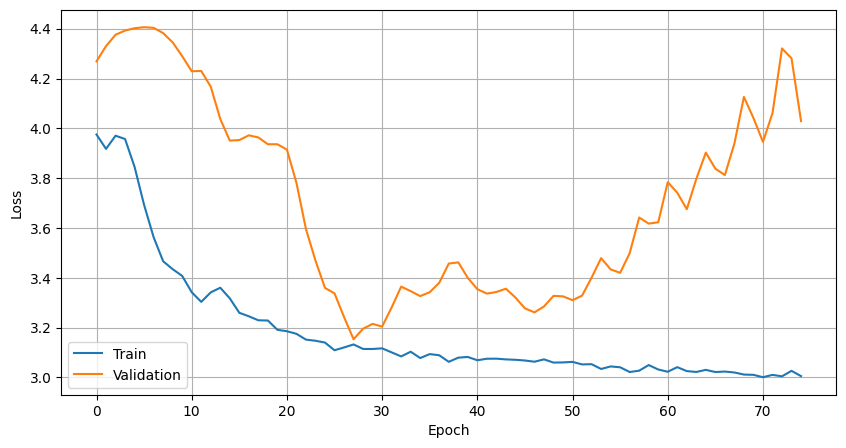

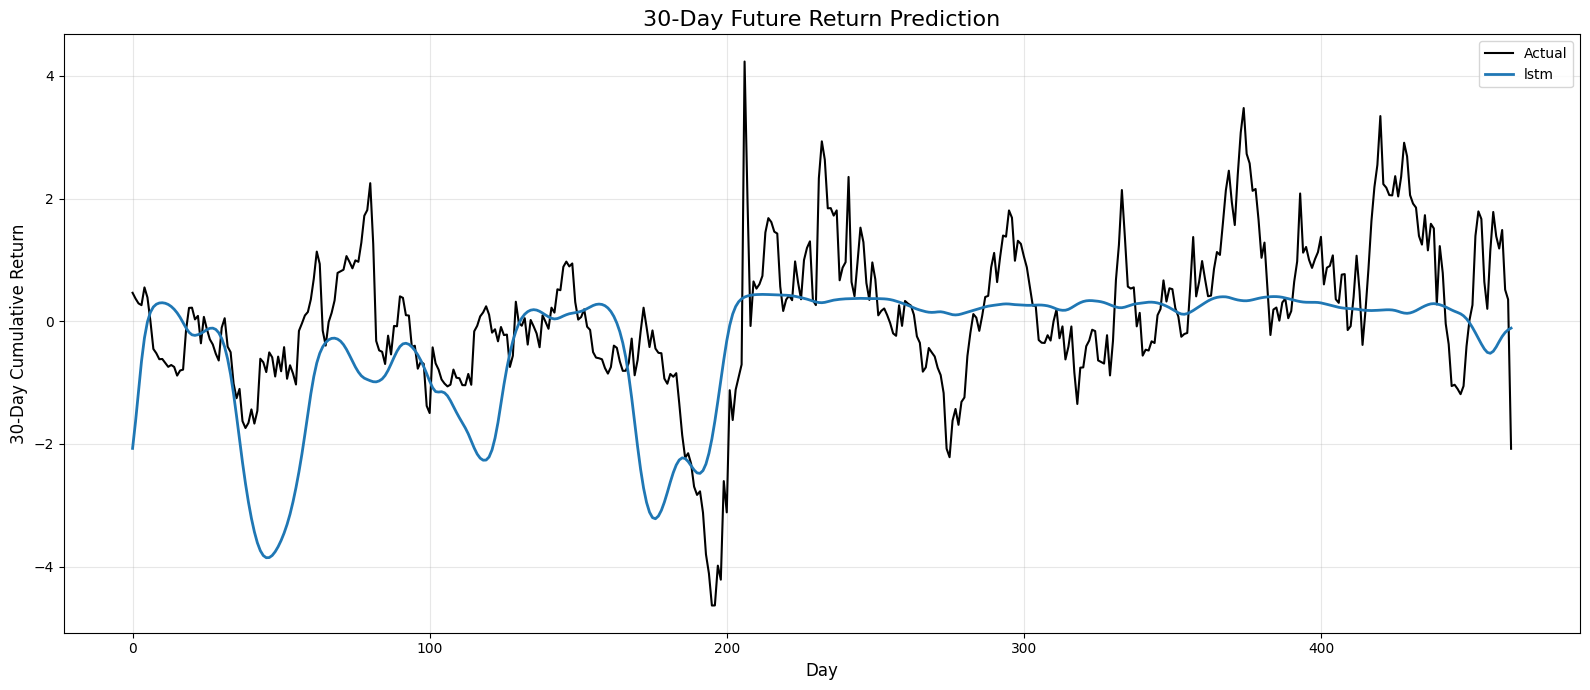


--- Training GRU | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_gru_batch_1_15.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN

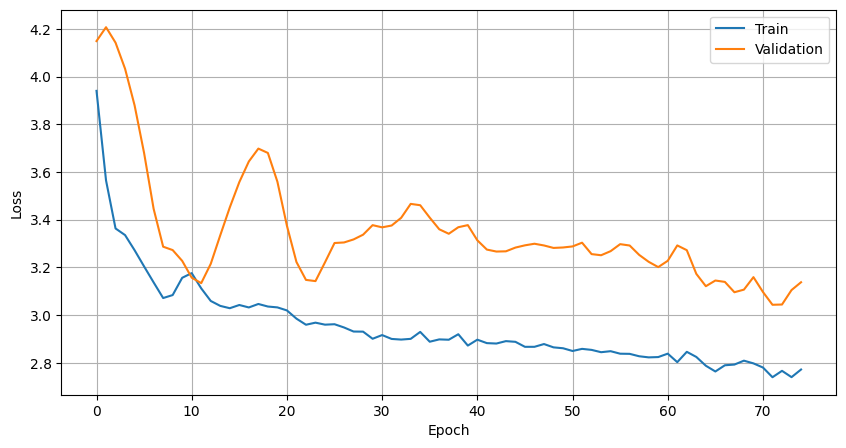

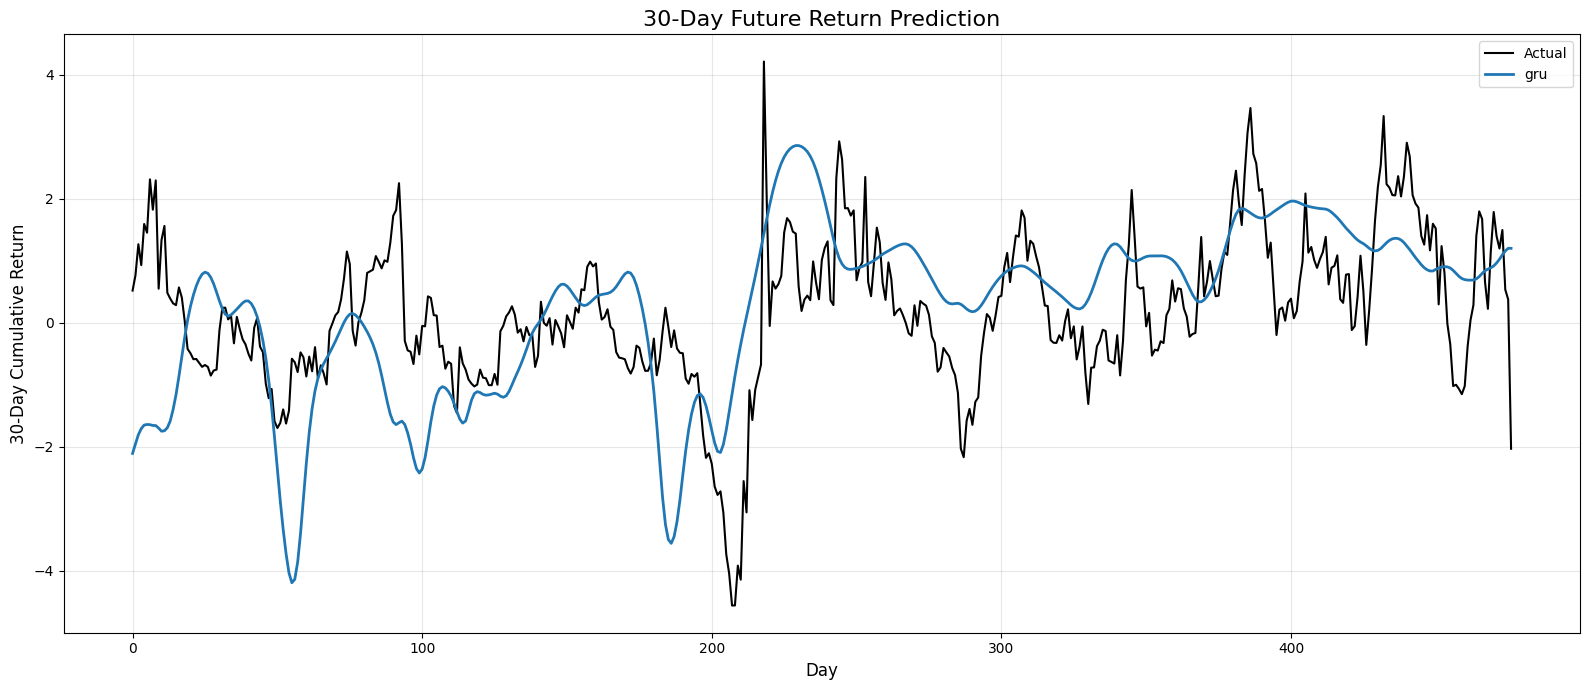


--- Training CNN | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_cnn_batch_1_15.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN

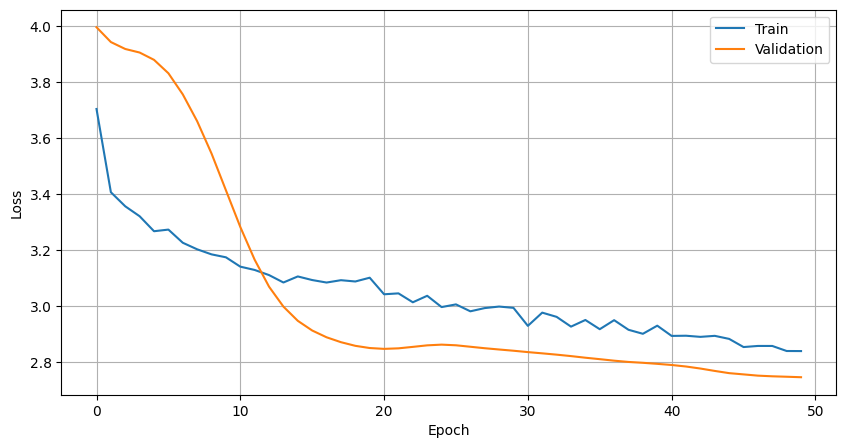

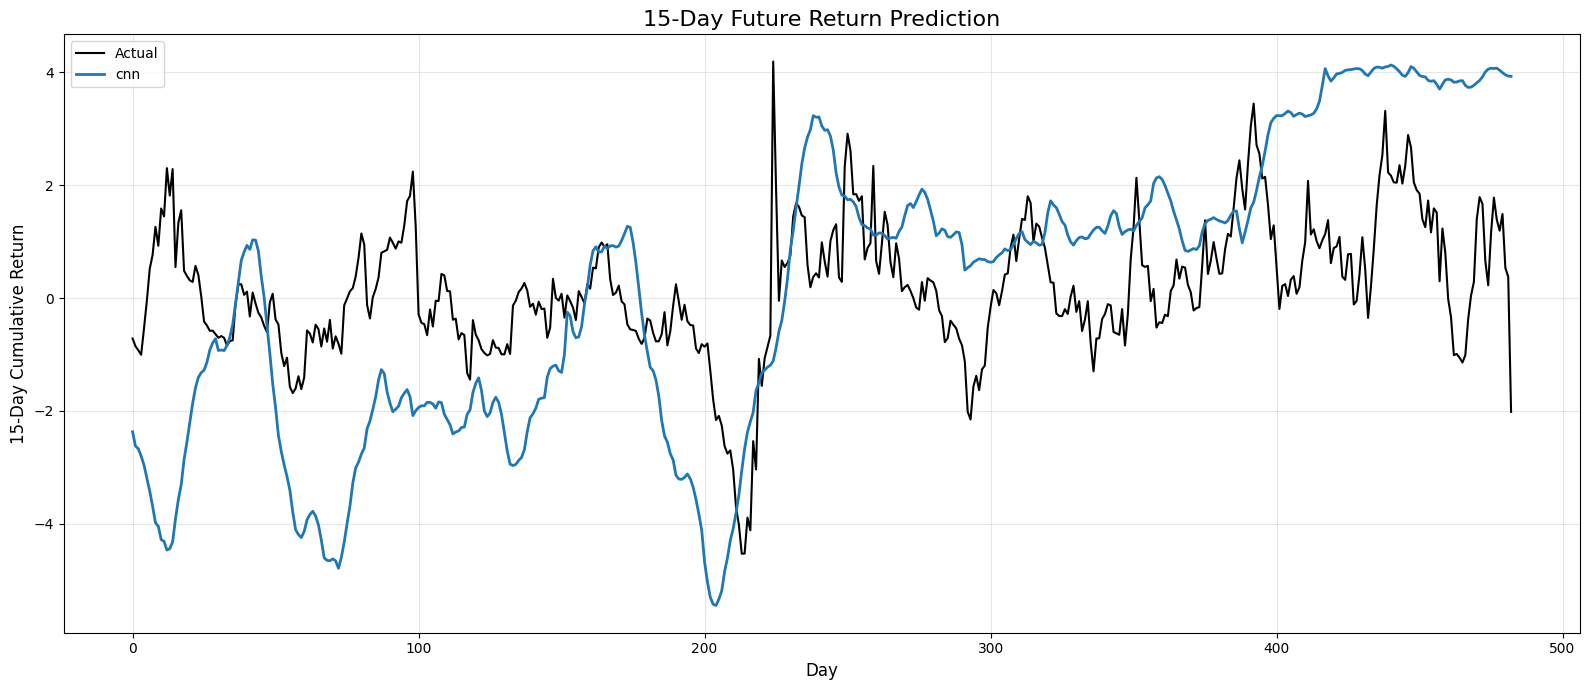


--- Training MLP | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_mlp_batch_1_15.pt
Configuration Loaded.
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470

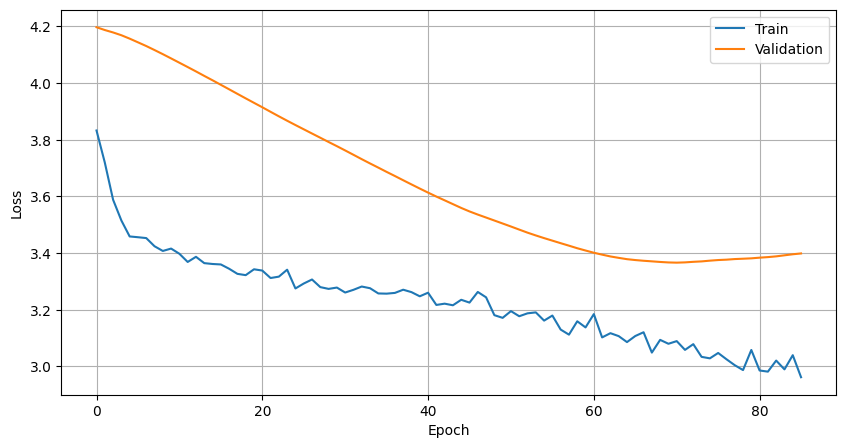

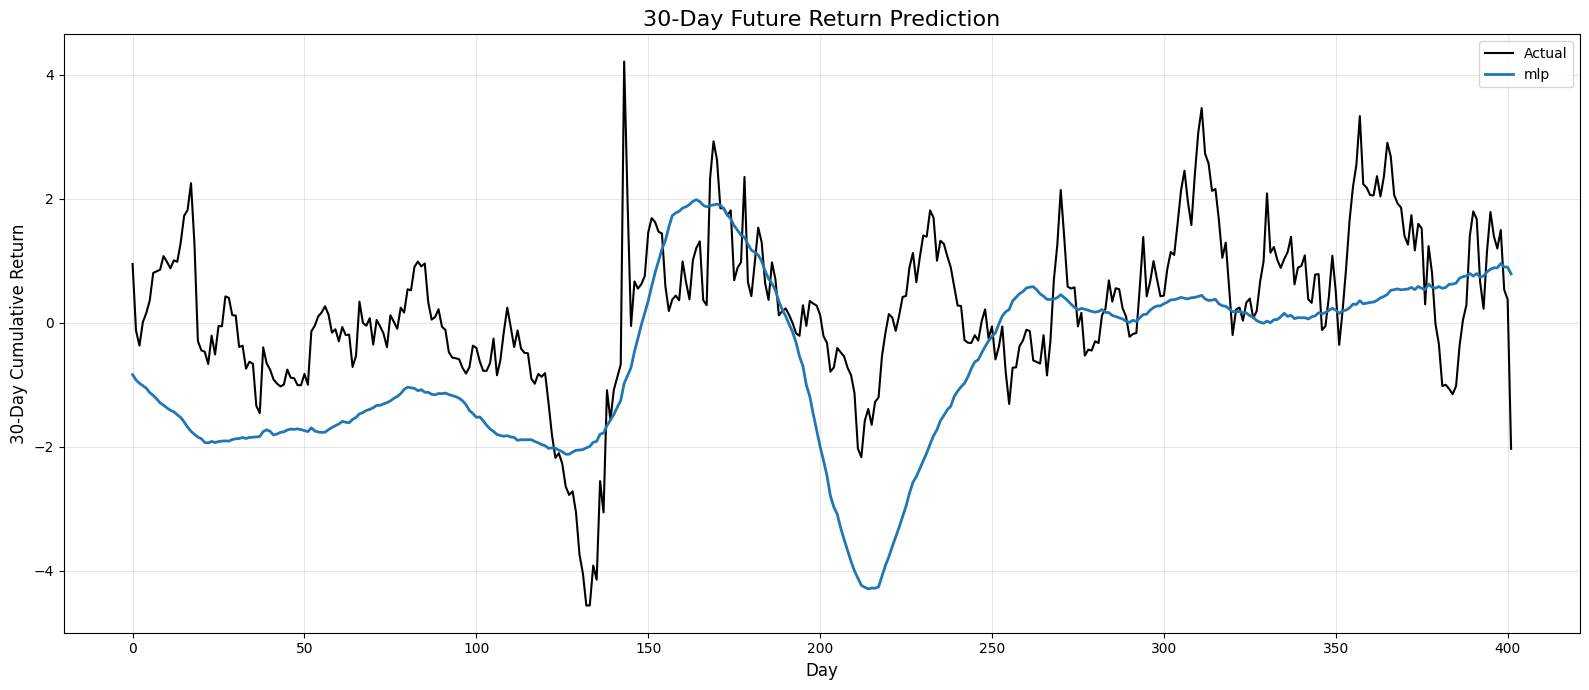


return 30 

--- Training LSTM | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_lstm_batch_1_30.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.8752

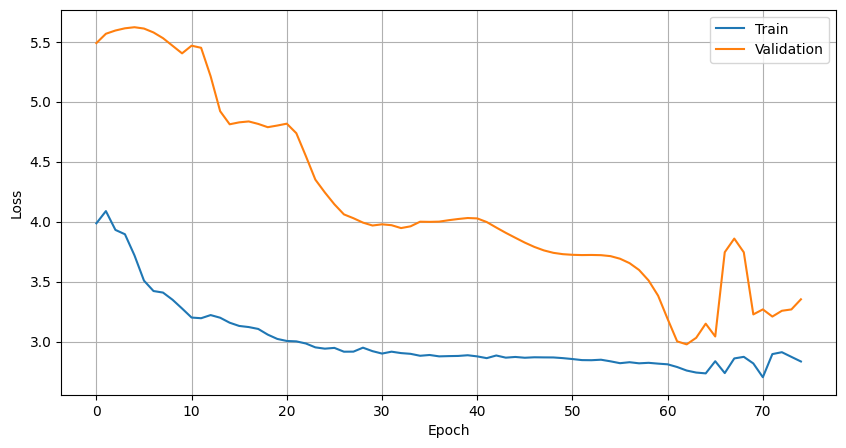

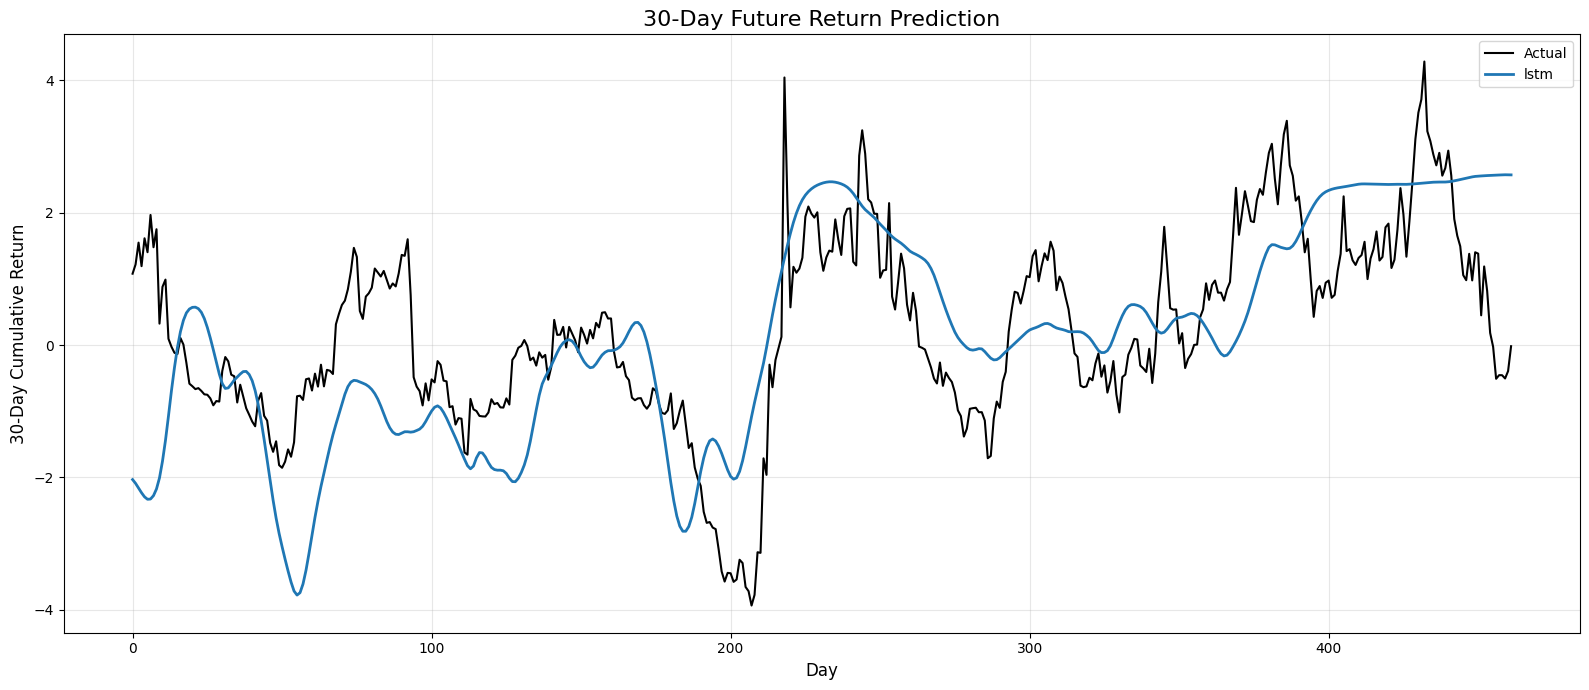


--- Training GRU | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_gru_batch_1_30.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN

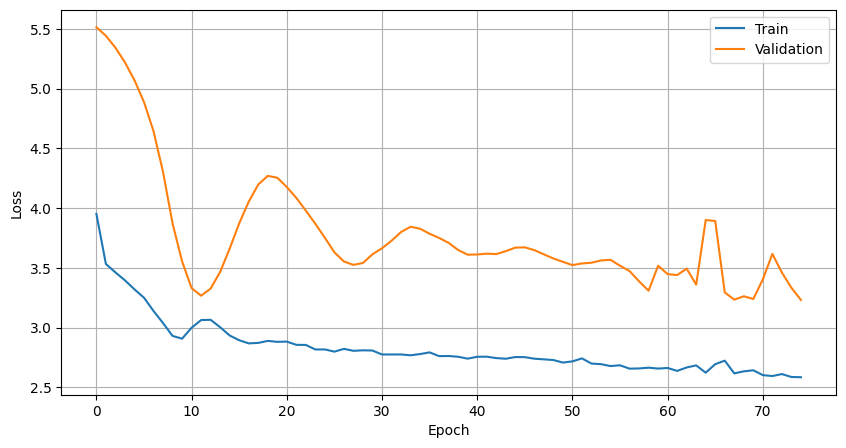

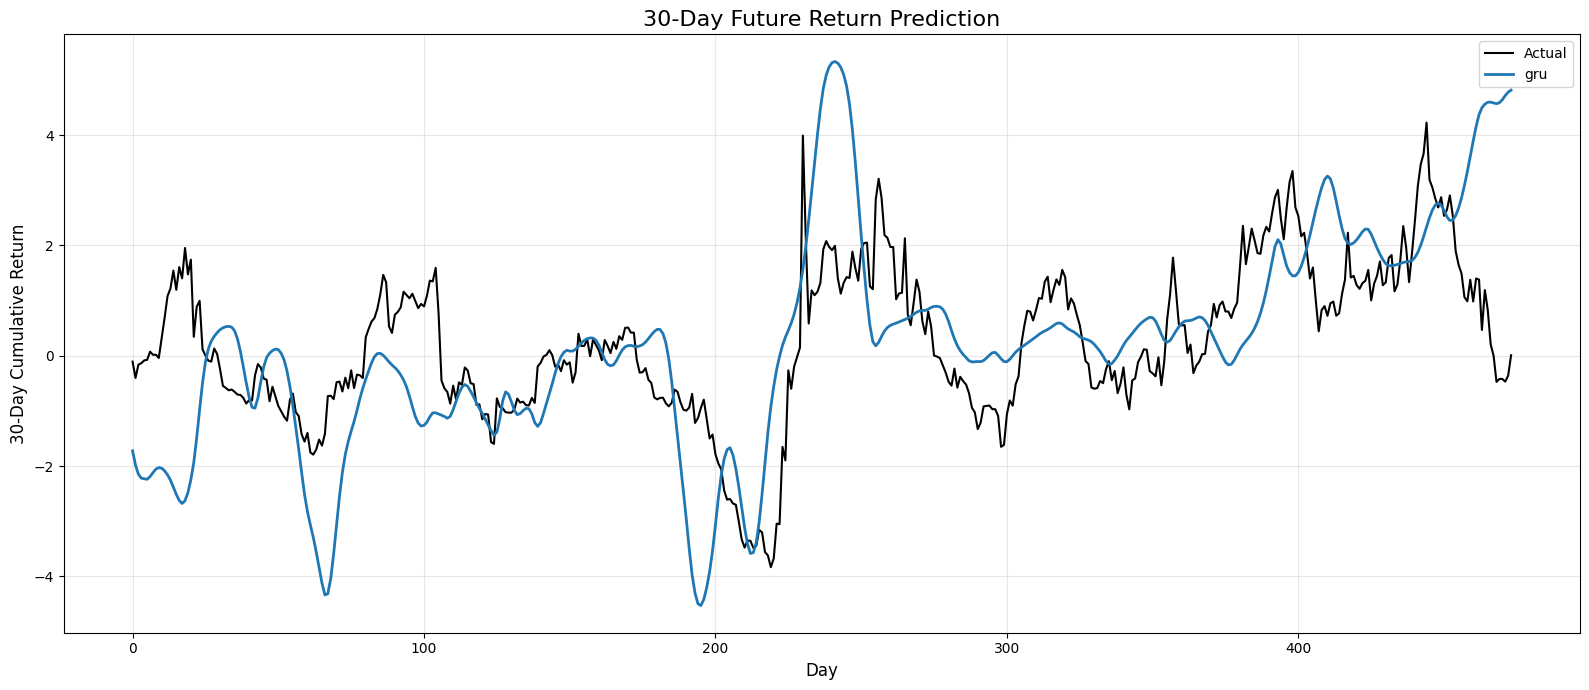


--- Training CNN | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_cnn_batch_1_30.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN

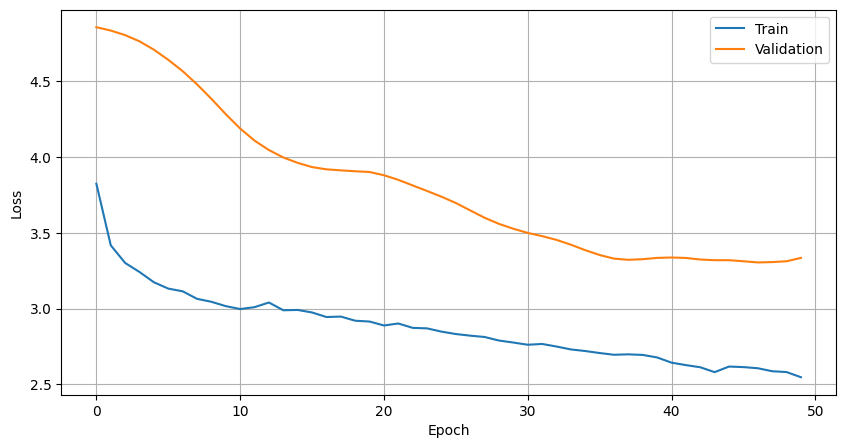

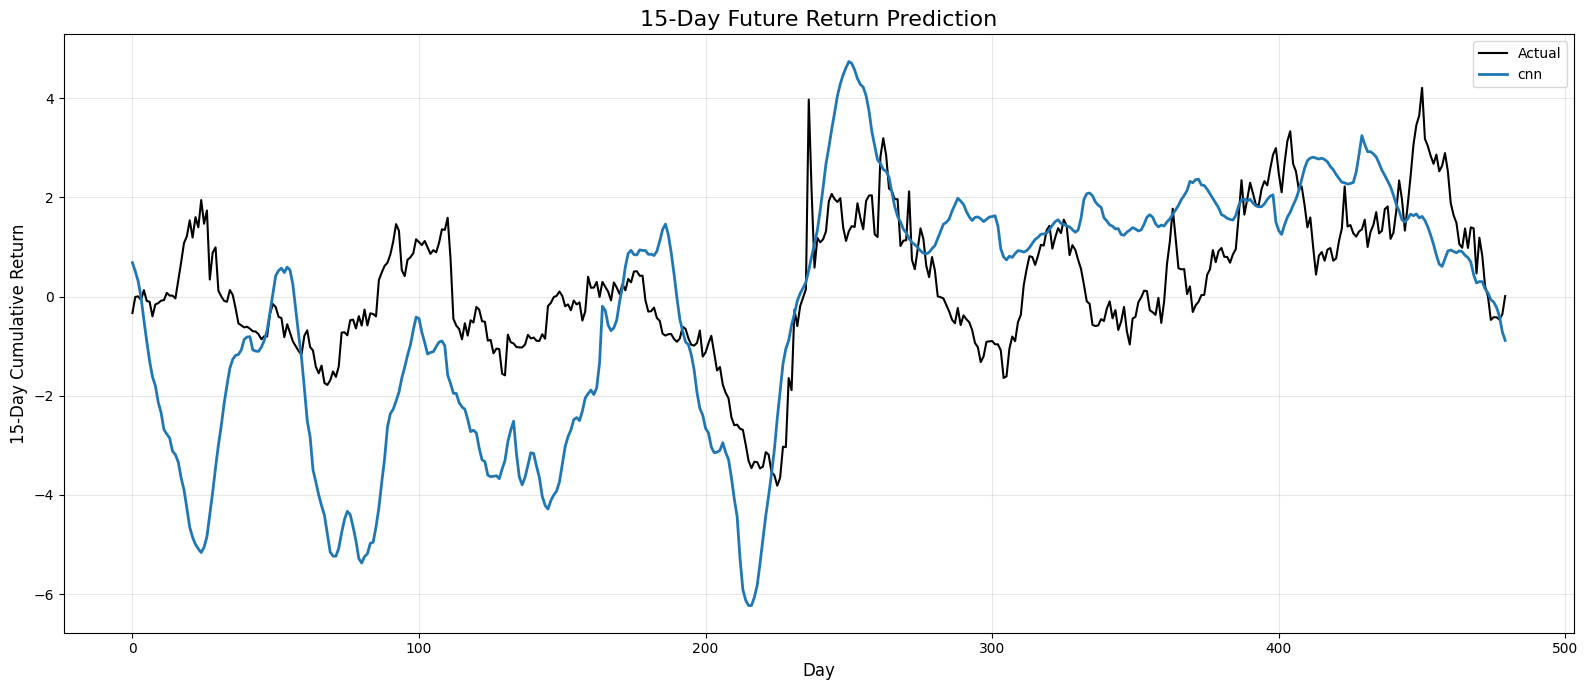


--- Training MLP | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_mlp_batch_1_30.pt
Configuration Loaded.
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470

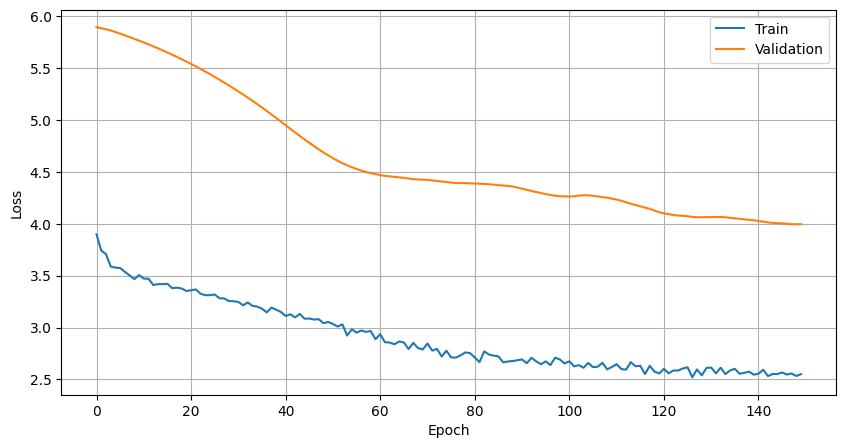

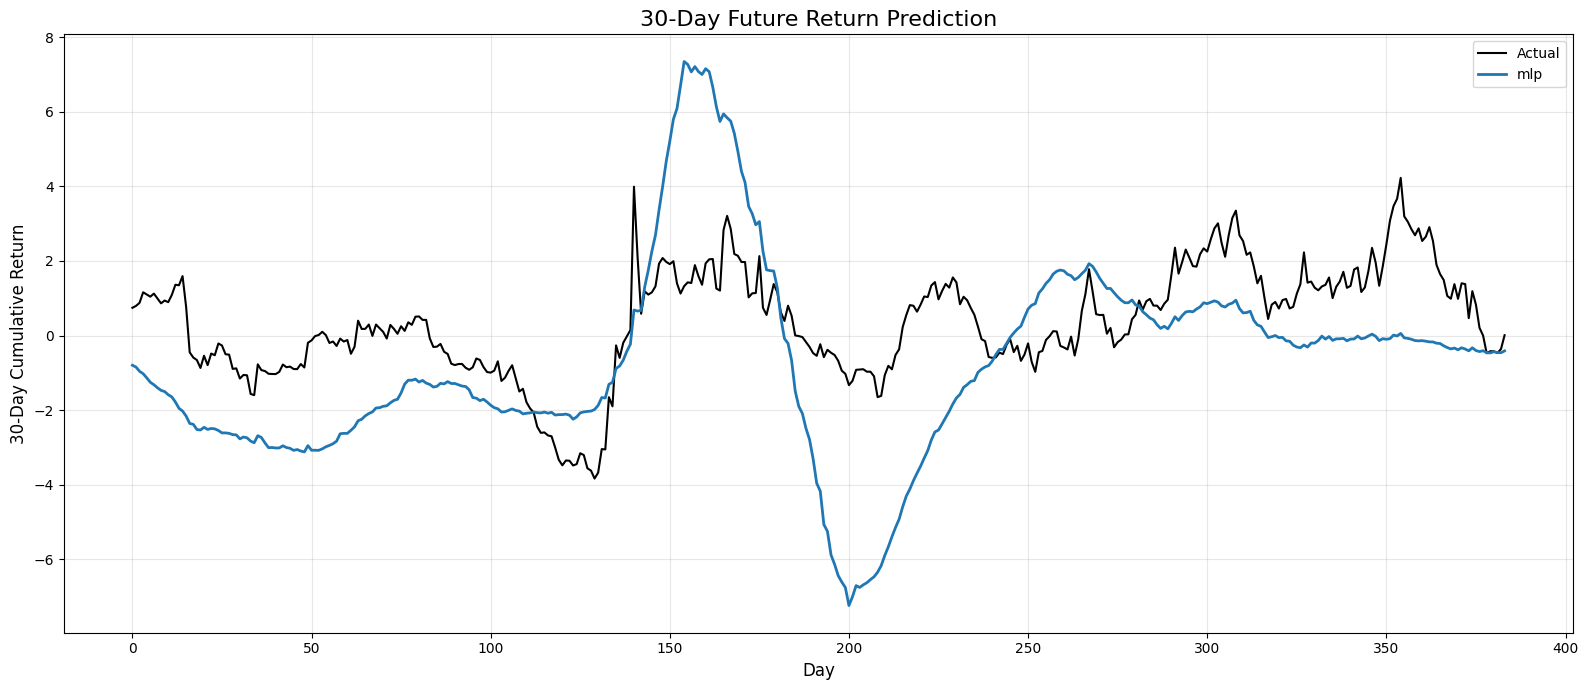


return 45 

--- Training LSTM | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_lstm_batch_1_45.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.8752

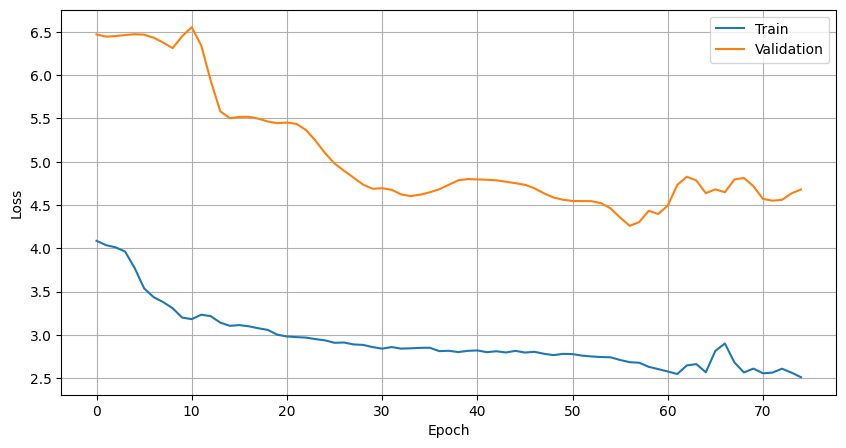

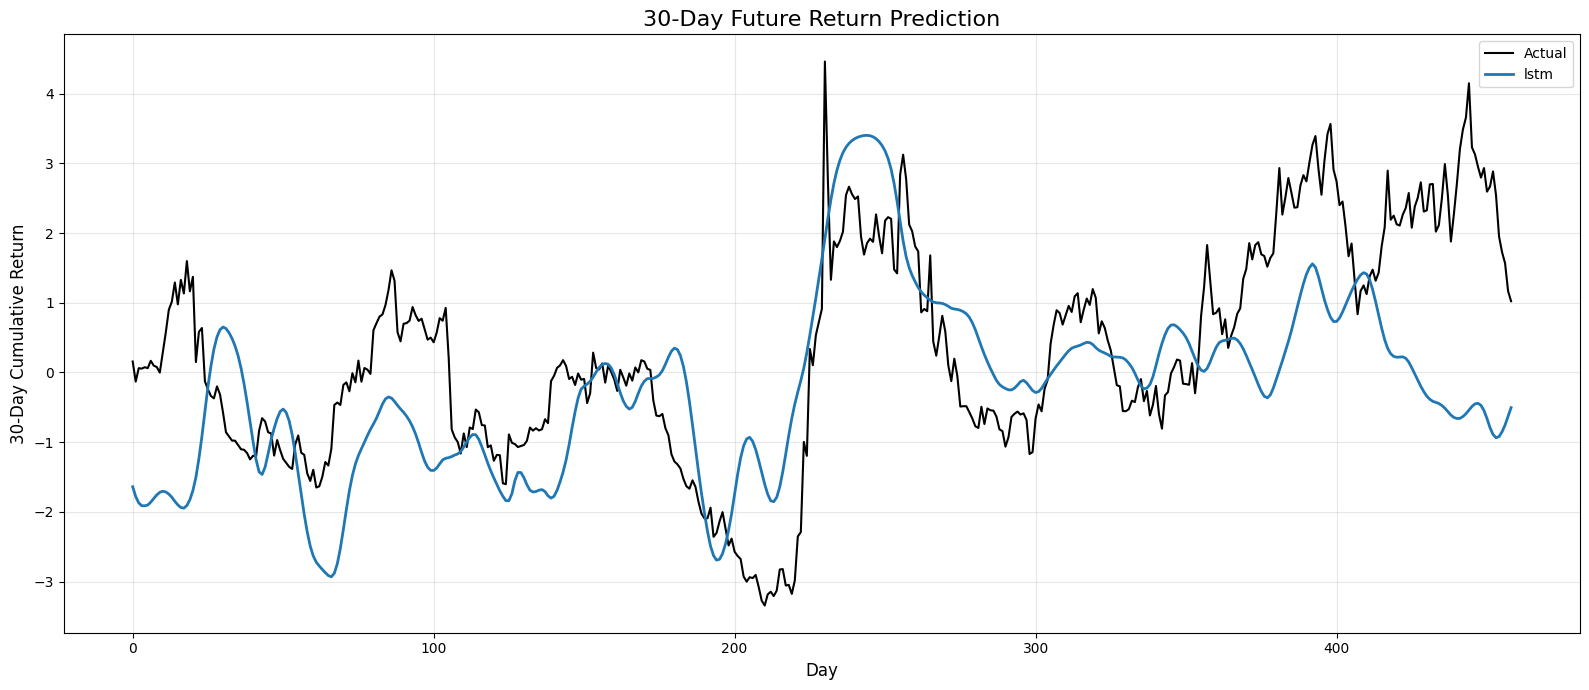


--- Training GRU | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_gru_batch_1_45.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN

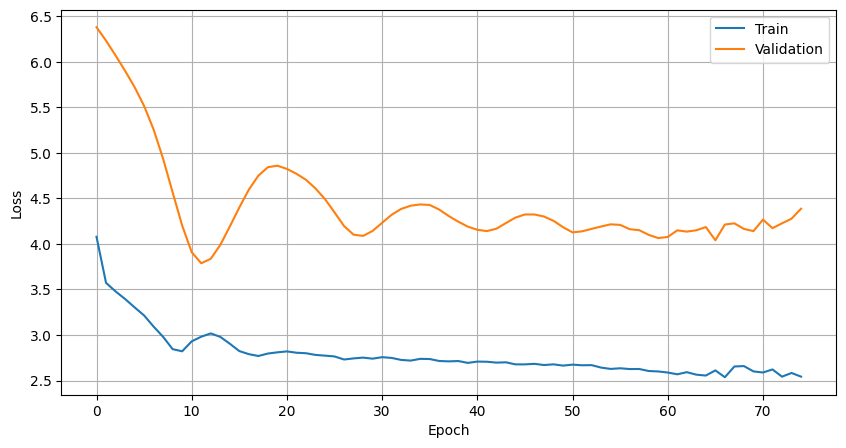

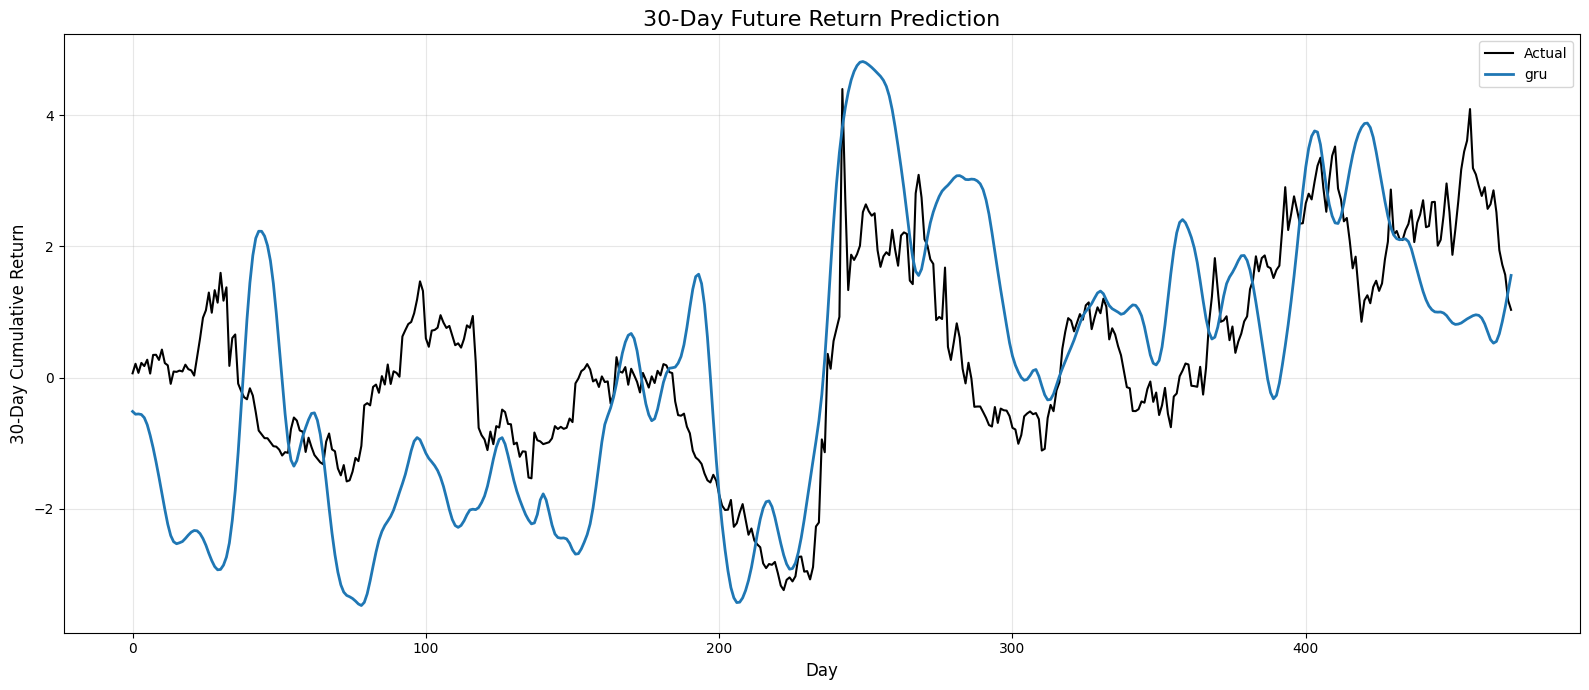


--- Training CNN | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_cnn_batch_1_45.pt
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN

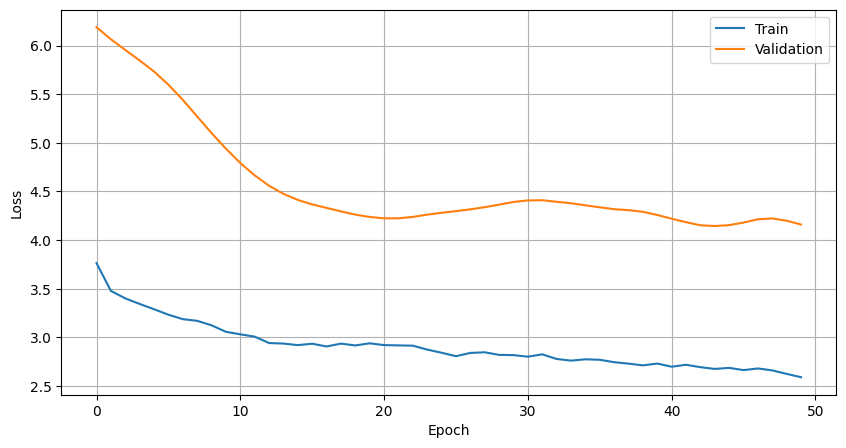

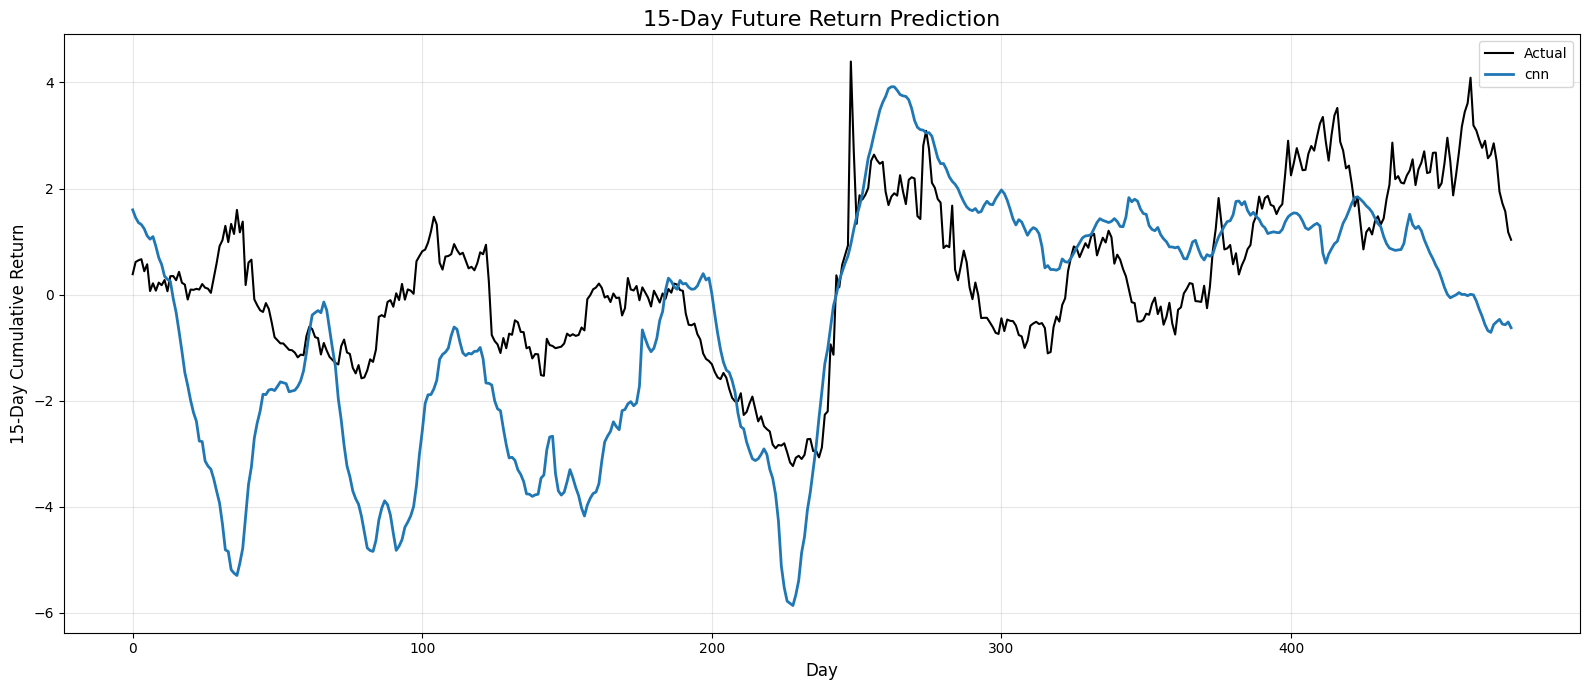


--- Training MLP | Batch 1 ---
Data  : D:\archive\ADANIPORTS.csv
Saving: checkpoint_6\agent_mlp_batch_1_45.pt
Configuration Loaded.
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470

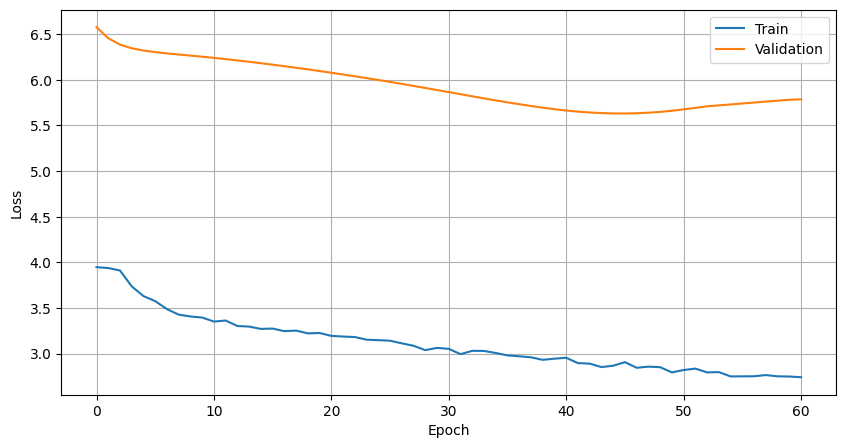

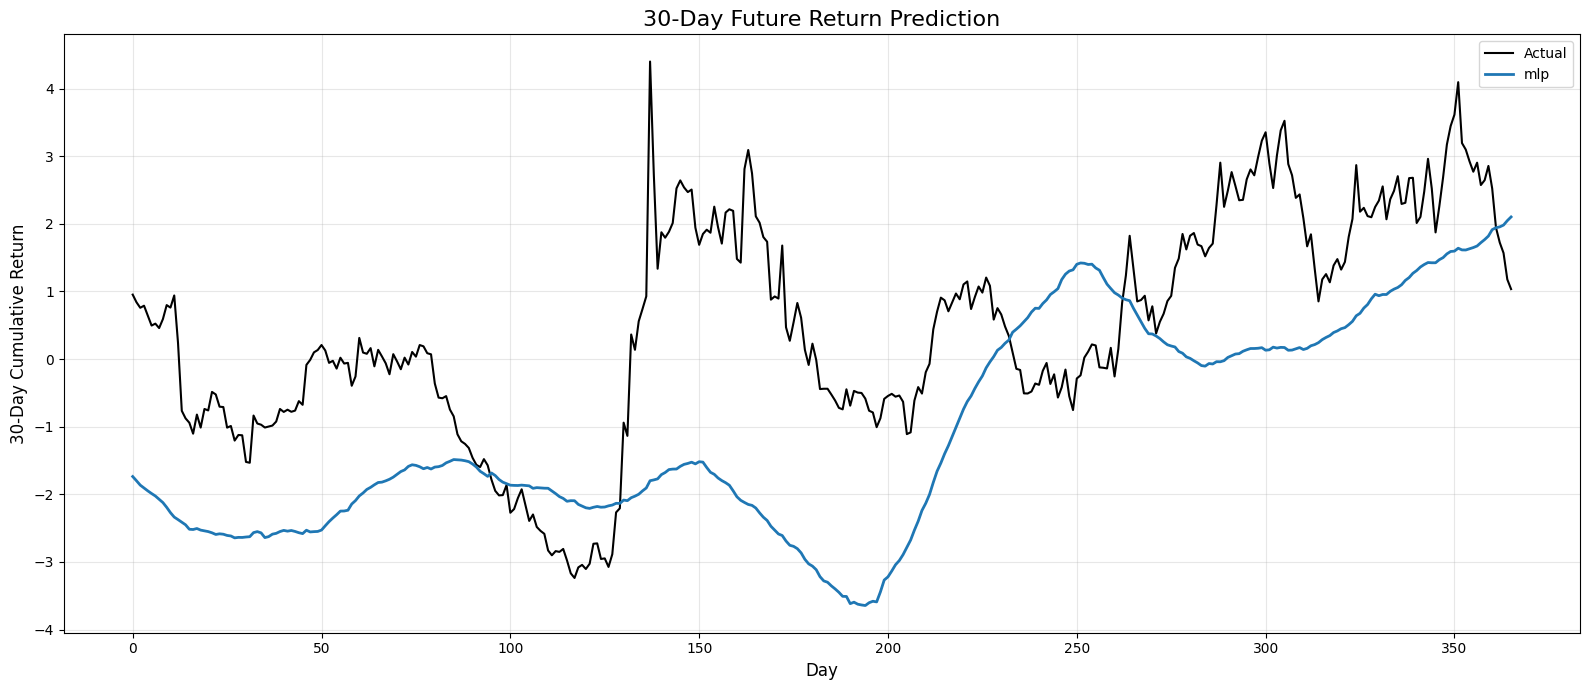


All batches finished.


In [24]:
import os
import glob

# ============================================================
# Main Training Loop
# ============================================================

DATA_DIR = r"D:\archive"
CHECKPOINT_DIR = "checkpoint_6"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Grab the first 5 CSV files in the archive directory
csv_files = [r"D:\archive\ADANIPORTS.csv"]

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

print(f"Found {len(csv_files)} files to train on:")
for f in csv_files:
    print(" -", f)

AGENTS = {
    "lstm": train_lstm,
    "gru": train_gru,
    "cnn": train_cnn,
    "mlp": train_mlp,
}

returns=[15,30,45]

def main():
    for batch_idx, data_path in enumerate(csv_files, start=1):
        # if batch_idx==1 or batch_idx>2:
        #     continue
        print("\n" + "=" * 60)
        print(f"BATCH {batch_idx} | File: {os.path.basename(data_path)}")
        print("=" * 60)

        for t in returns:
            print("\n" + "=" * 60)
            print(f"return {t} ")
            print("=" * 60)
            
            for agent_name, train_fn in AGENTS.items():

                model_path = os.path.join(
                    CHECKPOINT_DIR,
                    f"agent_{agent_name}_batch_{batch_idx}_{t}.pt",
                )

                print(f"\n--- Training {agent_name.upper()} | Batch {batch_idx} ---")
                print(f"Data  : {data_path}")
                print(f"Saving: {model_path}")

                try:
                    train_fn(data_path, model_path, f_days=t)
                except Exception as e:
                    print(f"[ERROR] {agent_name} on batch {batch_idx} failed: {e}")
                    continue

    print("\nAll batches finished.")


if __name__ == "__main__":
    main()

In [ ]:
# running simulation 

In [ ]:
import math

def agent_out(returns, range_stock=50, risk=0.5, fear=0.5, boldness=0.5, no_stocks=0, cash=10000, price=100 , nei=0):
    stock_ratio=no_stocks*price/(no_stocks*price+cash)
    e=(risk-stock_ratio)
    num_stocks=range_stock*math.tanh((returns*0.5+e+fear*nei)*(boldness+0.5))
    return num_stocks

ans=agent_out(1,nei=20)
print(ans)

49.99999997210532


In [18]:
val=0.0
no_stock=0
cash=10000
price=100
for i in range(10):
    if i==5:
        nei=0.6
    else:
        nei=0.0
    ans=agent_out(val,no_stocks=no_stock,cash=cash,price=price,nei=nei)
    print(val,ans,cash,price,no_stock,nei)
    val+=0.25
    if cash<price*ans:
        print("skip this")
        continue
    
    cash-=price*ans
    price=price*(1+val)
    no_stock+=ans
    

0.0 23.105857863000487 10000 100 0 0.0
0.25 16.905163869985316 7689.414213699951 125.0 23.105857863000487 0.0
0.5 8.72840471260951 5576.268729951786 187.5 40.0110217329858 0.0
0.75 3.6262982316297867 3939.6928463375025 328.125 48.73942644559531 0.0
1.0 3.6977052062759106 2749.813739083979 656.25 52.3657246772251 0.0
1.25 20.219621531490155 323.19469746541245 1476.5625 56.063429883501016 0.6
skip this
1.5 12.428545207038702 323.19469746541245 1476.5625 56.063429883501016 0.0
skip this
1.75 18.087112903406517 323.19469746541245 1476.5625 56.063429883501016 0.0
skip this
2.0 23.25850839838455 323.19469746541245 1476.5625 56.063429883501016 0.0
skip this
2.25 27.864337346564337 323.19469746541245 1476.5625 56.063429883501016 0.0
skip this


In [1]:
# ============================================================
# Imports
# ============================================================


import os
import math
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


# ============================================================
# Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

c:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# CELL — Market Model
# ============================================================

VOL_WINDOW = 20  # matches MA20 / rolling-vol convention used elsewhere in the notebook

class MarketModel(nn.Module):
    def __init__(self, max_daily_move=0.15):
        super().__init__()
        self.max_daily_move = max_daily_move
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        raw = self.net(x).squeeze(-1)
        return torch.tanh(raw) * self.max_daily_move   # bounded to +/- 15% per day

In [3]:
# ============================================================
# CELL — feature extraction: day's agent signals + price history -> 10 features
# ============================================================
def extract_market_features(day_signals: dict, price_history: list) -> list:
    signals = list(day_signals.values())
    pos = [s for s in signals if s > 0]
    neg = [s for s in signals if s < 0]

    buy_volume = sum(pos) if pos else 0.0
    sell_volume = sum(abs(s) for s in neg) if neg else 0.0
    buyer_count = len(pos)
    seller_count = len(neg)
    mean_buy = (buy_volume / buyer_count) if buyer_count else 0.0
    mean_sell = (sell_volume / seller_count) if seller_count else 0.0

    prev_price = price_history[-1]
    prev_return = ((price_history[-1] - price_history[-2]) / price_history[-2]
                   if len(price_history) >= 2 else 0.0)

    recent = price_history[-(VOL_WINDOW + 1):]
    if len(recent) >= 2:
        rets = [(recent[i] - recent[i - 1]) / recent[i - 1] for i in range(1, len(recent))]
        volatility = float(np.std(rets))
    else:
        volatility = 0.0

    ma_window = price_history[-VOL_WINDOW:] if len(price_history) >= VOL_WINDOW else price_history
    ma20 = float(np.mean(ma_window))
    momentum = (prev_price - ma20) / ma20 if ma20 != 0 else 0.0

    return [buy_volume, sell_volume, buyer_count, seller_count,
            mean_buy, mean_sell, prev_price, prev_return, volatility, momentum]

In [50]:
# ============================================================
# CELL — extract_market_features [FIXED: prev_price normalized]
# Replaces raw price level with a scale-free position relative to
# recent price range, so no single feature dominates the network's
# first layer regardless of the instrument's absolute price level.
# ============================================================

def extract_market_features(day_signals: dict, price_history: list) -> list:
    signals = list(day_signals.values())
    pos = [s for s in signals if s > 0]
    neg = [s for s in signals if s < 0]

    buy_volume = sum(pos) if pos else 0.0
    sell_volume = sum(abs(s) for s in neg) if neg else 0.0
    buyer_count = len(pos)
    seller_count = len(neg)
    mean_buy = (buy_volume / buyer_count) if buyer_count else 0.0
    mean_sell = (sell_volume / seller_count) if seller_count else 0.0

    prev_price = price_history[-1]
    prev_return = ((price_history[-1] - price_history[-2]) / price_history[-2]
                   if len(price_history) >= 2 else 0.0)

    recent = price_history[-(VOL_WINDOW + 1):]
    if len(recent) >= 2:
        rets = [(recent[i] - recent[i - 1]) / recent[i - 1] for i in range(1, len(recent))]
        volatility = float(np.std(rets))
    else:
        volatility = 0.0

    ma_window = price_history[-VOL_WINDOW:] if len(price_history) >= VOL_WINDOW else price_history
    ma20 = float(np.mean(ma_window))
    momentum = (prev_price - ma20) / ma20 if ma20 != 0 else 0.0

    # --- normalized price level: position within recent [min, max] range, in [-1, 1] ---
    range_window = price_history[-VOL_WINDOW:] if len(price_history) >= VOL_WINDOW else price_history
    range_min, range_max = min(range_window), max(range_window)
    span = range_max - range_min
    price_level_norm = (2 * (prev_price - range_min) / span - 1) if span > 1e-8 else 0.0

    return [buy_volume, sell_volume, buyer_count, seller_count,
            mean_buy, mean_sell, price_level_norm, prev_return, volatility, momentum]

In [51]:
# ============================================================
# CELL — shared feature prep for the market-model pipeline
# (builds every column any of the 4 agent architectures needs,
#  in one df, so all windows share the same day index)
# ============================================================

TS_FEATURES = [
    "close_norm", "daily_return", "volume_norm",
    "vwap_distance", "volatility", "ma20_distance",
]

MLP_FEATURES = [
    "close_norm", "daily_return", "volume_norm", "vwap_distance",
    "momentum_15", "momentum_30", "momentum_60",
    "volatility_15", "volatility_30", "volatility_60",
]

AGENT_LOOKBACK = {"lstm": 120, "gru": 60, "cnn": 30, "mlp": 60}
AGENT_FEATKEY  = {"lstm": "ts", "gru": "ts", "cnn": "ts", "mlp": "mlp"}
AGENT_CLASS    = {
    "lstm": LSTMReturnPredictor,
    "gru":  GRUReturnPredictor,
    "cnn":  CNNReturnPredictor,
    "mlp":  MLPReturnPredictor,
}


def prepare_market_data(DATA_PATH):

    df = pd.read_csv(DATA_PATH)

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")

    df = df.reset_index(drop=True)

    df["daily_return"] = (df["Close"] - df["Prev Close"]) / df["Prev Close"]
    df["MA20"] = df["Close"].rolling(20).mean()
    df["volatility"] = df["daily_return"].rolling(20).std()
    df["vwap_distance"] = (df["Close"] - df["VWAP"]) / df["VWAP"]
    df["ma20_distance"] = (df["Close"] - df["MA20"]) / df["MA20"]
    df["log_volume"] = np.log1p(df["Volume"])

    for n in (15, 30, 60):
        df[f"momentum_{n}"] = (df["Close"] - df["Close"].shift(n)) / df["Close"].shift(n)
        df[f"volatility_{n}"] = df["daily_return"].rolling(n).std()

    df = df.dropna().reset_index(drop=True)

    close_mean, close_std = df["Close"].mean(), df["Close"].std()
    df["close_norm"] = (df["Close"] - close_mean) / (close_std + 1e-8)

    vol_mean, vol_std = df["log_volume"].mean(), df["log_volume"].std()
    df["volume_norm"] = (df["log_volume"] - vol_mean) / (vol_std + 1e-8)

    return df

In [52]:
# ============================================================
# CELL — population: 12 frozen working agents (4 types x 3 horizons) + 8 random agents
# ============================================================

def load_state_dict_flexible(path, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        return ckpt["model_state_dict"]
    return ckpt  # already a raw state_dict


def build_population(checkpoint_dir, batch_idx=1, horizons=(15, 30, 45), n_random=8, device="cpu"):

    population = []
    agent_id = 0

    for atype in ["lstm", "gru", "cnn", "mlp"]:

        feat_key = AGENT_FEATKEY[atype]
        input_size = len(TS_FEATURES) if feat_key == "ts" else len(MLP_FEATURES)
        hparams = AGENT_HPARAMS[atype]

        for horizon in horizons:

            ckpt_path = os.path.join(
                checkpoint_dir, f"agent_{atype}_batch_{batch_idx}_{horizon}.pt"
            )

            model = AGENT_CLASS[atype](input_size=input_size, **hparams)
            model.load_state_dict(load_state_dict_flexible(ckpt_path, device))
            model.eval()

            for p in model.parameters():
                p.requires_grad_(False)   # frozen — no gradients into agent models

            population.append({
                "id": agent_id,
                "type": atype,
                "horizon": horizon,
                "model": model,
                "lookback": AGENT_LOOKBACK[atype],   # architecture-fixed, not horizon-dependent
                "features_key": feat_key,
            })
            agent_id += 1

    for _ in range(n_random):
        population.append({
            "id": agent_id, "type": "random", "horizon": None, "model": None,
            "lookback": 1, "features_key": None,
        })
        agent_id += 1

    n_working = 4 * len(horizons)
    print(f"Population built: {agent_id} agents "
          f"({n_working} working [4 types x {len(horizons)} horizons] / {n_random} random)")

    return population

In [53]:
# ============================================================
# CELL — per-architecture hyperparameters (must match train_* functions exactly)
# ============================================================

AGENT_HPARAMS = {
    "lstm": {"hidden_size": 128, "num_layers": 4, "dropout": 0.3},
    "gru":  {"hidden_size": 128, "num_layers": 4, "dropout": 0.3},
    "cnn":  {"hidden_size": 64,  "num_layers": 2, "dropout": 0.5},
    "mlp":  {"hidden_size": 64,  "dropout": 0.4},   # MLPReturnPredictor has no num_layers arg
}

In [54]:
# ============================================================
# CELL — build (X, Y) dataset for the market model
# X = extract_market_features(...) per real day
# Y = realized next-day return on the real series (teacher forcing)
# Agents are frozen and stateless here — no cash / no_stocks / fear used.
# ============================================================

def build_market_dataset(DATA_PATH, population, min_history=30):

    df = prepare_market_data(DATA_PATH)

    close = df["Close"].values.astype(np.float32)
    daily_return = df["daily_return"].values.astype(np.float32)

    feat_mats = {
        "ts":  df[TS_FEATURES].values.astype(np.float32),
        "mlp": df[MLP_FEATURES].values.astype(np.float32),
    }

    max_lookback = max(a["lookback"] for a in population if a["type"] != "random")
    start_t = max(max_lookback - 1, VOL_WINDOW, min_history)
    end_t = len(df) - 2   # need day t and realized return at t+1

    X, Y = [], []

    for t in range(start_t, end_t + 1):

        day_signals = {}

        for a in population:
            if a["type"] == "random":
                day_signals[a["id"]] = float(np.random.randn() * 0.5)
                continue

            lb = a["lookback"]
            window = feat_mats[a["features_key"]][t - lb + 1: t + 1]
            x = torch.tensor(window, dtype=torch.float32).unsqueeze(0)

            with torch.no_grad():
                day_signals[a["id"]] = a["model"](x).item()

        price_history = close[: t + 1].tolist()   # real prices, up to & including day t
        features = extract_market_features(day_signals, price_history)
        target_return = float(daily_return[t + 1])  # realized return t -> t+1

        X.append(features)
        Y.append(target_return)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

    print("Market dataset built")
    print("Feature Shape :", X.shape)
    print("Target Shape  :", Y.shape)

    return X, Y

In [55]:
# ============================================================
# CELL — train the market model (only this model gets gradients)
# ============================================================

def train_market_model(
    DATA_PATH,
    MODEL_PATH,
    population,
    num_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    train_ratio=0.8,
):

    X, Y = build_market_dataset(DATA_PATH, population)

    split = int(len(X) * train_ratio)

    X_train, Y_train = X[:split], Y[:split]
    X_val, Y_val = X[split:], Y[split:]

    print()
    print("Train Samples      :", len(X_train))
    print("Validation Samples :", len(X_val))

    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32).squeeze(-1)

    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32).squeeze(-1)

    model = MarketModel()
    print(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    train_losses, val_losses = [], []

    for epoch in tqdm(range(num_epochs)):

        model.train()
        optimizer.zero_grad()

        pred = model(X_train)
        loss = loss_fn(pred, Y_train)

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = loss_fn(val_pred, Y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss.item() < best_val:
            best_val = val_loss.item()
            torch.save(model.state_dict(), MODEL_PATH)

        if epoch % 20 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:4d} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}")

    loss_plot(train_losses, val_losses)

    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    with torch.no_grad():
        val_pred = model(X_val).numpy()

    Metrics(Y_val.numpy(), val_pred)

    return model

In [56]:

population = build_population(
    CHECKPOINT_DIR, batch_idx=1, horizons=(15, 30, 45), n_random=8
)

Population built: 20 agents (12 working [4 types x 3 horizons] / 8 random)


Population built: 20 agents (12 working [4 types x 3 horizons] / 8 random)
Market dataset built
Feature Shape : (2336, 10)
Target Shape  : (2336, 1)

Train Samples      : 1868
Validation Samples : 468
MarketModel(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


 44%|████▍     | 89/200 [00:00<00:00, 440.21it/s]

Epoch    0 | Train Loss: 0.023080 | Val Loss: 0.022350
Epoch   20 | Train Loss: 0.000936 | Val Loss: 0.007546
Epoch   40 | Train Loss: 0.001133 | Val Loss: 0.001082
Epoch   60 | Train Loss: 0.000713 | Val Loss: 0.000748
Epoch   80 | Train Loss: 0.000629 | Val Loss: 0.000708


 67%|██████▋   | 134/200 [00:00<00:00, 363.10it/s]

Epoch  100 | Train Loss: 0.000602 | Val Loss: 0.000674
Epoch  120 | Train Loss: 0.000587 | Val Loss: 0.000663
Epoch  140 | Train Loss: 0.000577 | Val Loss: 0.000656
Epoch  160 | Train Loss: 0.000570 | Val Loss: 0.000651


100%|██████████| 200/200 [00:00<00:00, 350.68it/s]


Epoch  180 | Train Loss: 0.000565 | Val Loss: 0.000649
Epoch  199 | Train Loss: 0.000561 | Val Loss: 0.000647


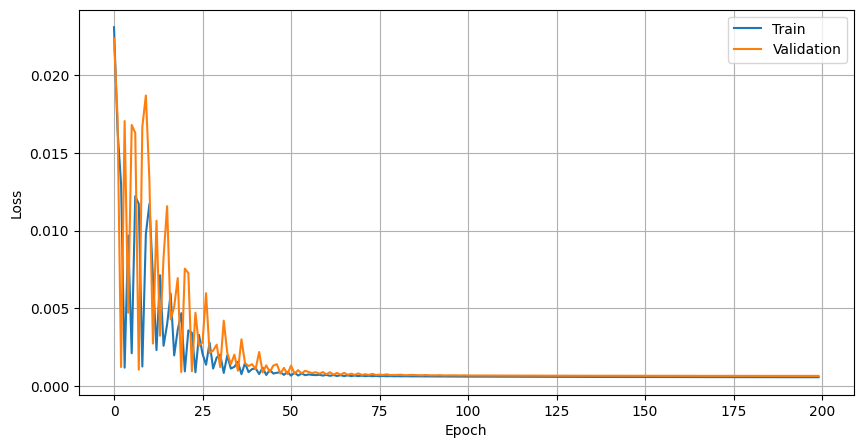


MAE               : 0.016756
RMSE              : 0.025443
Correlation       : 0.1088
Direction Accuracy: 0.5449


In [49]:
# ============================================================
# CELL — run: build population, train market model, save checkpoint
# ============================================================

CHECKPOINT_DIR = r"C:\Users\user\.vscode\abms\files\checkpoint_6"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DATA_PATH = r"D:\archive\ADANIPORTS.csv"   # same instrument the 12 agents were trained on

# population = build_population(
#     CHECKPOINT_DIR, batch_idx=1, f_days=30, n_each=3, n_random=8
# )

population = build_population(
    CHECKPOINT_DIR, batch_idx=1, horizons=(15, 30, 45), n_random=8
)

MARKET_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "market_model.pt")

market_model = train_market_model(
    DATA_PATH, MARKET_MODEL_PATH, population, num_epochs=200
)

In [69]:
# ============================================================
# CELL — simulation constants
# ============================================================

NORM = 0.5          # normalization constant applied to agent forecast r
E_SCALE = 1.5        # scaling constant c in the portfolio-pressure term e
N_AGENTS = 20         # 12 working + 8 random, matches build_population output
NEI_CHOICES = (4, 5)  # each agent has 4 or 5 neighbors
STARTING_CASH = 1000000.0
CHECKPOINT_DIR=r"C:\Users\user\.vscode\abms\files\checkpoint_6"

# ============================================================

DROPOUT_RATE = 0.5   # fraction of agents inactive on any given day (~10 of 20 trade)

In [70]:
# ============================================================
# CELL — reference scale used ONLY to keep training-time signal units
# consistent with simulation-time action units (no personality involved)
# ============================================================

REFERENCE_RANGE_STOCK = 7.5   # midpoint of the (25, 50) range_stock draw

In [71]:
# ============================================================
# CELL — neighbor graph (fixed for the whole simulation run)
# ============================================================

def build_neighbor_graph(n_agents=N_AGENTS, k_choices=NEI_CHOICES, seed=SEED):
    rng = random.Random(seed)
    graph = {}
    for i in range(n_agents):
        k = rng.choice(k_choices)
        candidates = [j for j in range(n_agents) if j != i]
        graph[i] = rng.sample(candidates, k)
    return graph

In [72]:
# ============================================================
# CELL — SimAgent: wraps a frozen forecaster with personality + dynamic state
# ============================================================

class SimAgent:
    def __init__(self, agent_id, atype, model, lookback, features_key, horizon=None):
        self.id = agent_id
        self.type = atype                 # "lstm" / "gru" / "cnn" / "mlp" / "random"
        self.model = model                # frozen nn.Module, or None for random
        self.lookback = lookback
        self.features_key = features_key
        self.horizon = horizon

        # personality — sampled once, fixed for the whole run
        self.risk = random.uniform(1e-6, 1 - 1e-6)      # (0, 1) exclusive
        self.boldness = random.uniform(0.5, 1.0)
        self.range_stock = random.randint(5, 10)
        self.fear = random.uniform(0.5, 1.0)

        # dynamic state
        self.no_stocks = 0
        self.cash = STARTING_CASH
        self.alive = True
        self.last_action = 0.0            # for neighbors' peer-influence term

    def forecast(self, feat_mats, t):
        if self.type == "random":
            return float(np.random.randn() * 0.5)   # noise agent, no learned signal
        lb = self.lookback
        window = feat_mats[self.features_key][t - lb + 1: t + 1]
        x = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            return self.model(x).item()

    def decide(self, r, price, neighbor_ids, agents_by_id):
        if not self.alive:
            return 0

        stock_ratio = (self.no_stocks * price) / (self.no_stocks * price + self.cash + 1e-8)
        e = (self.risk - stock_ratio) * E_SCALE

        nei_actions = [agents_by_id[n].last_action for n in neighbor_ids]
        eff = self.fear * (sum(nei_actions) / (len(nei_actions)*self.range_stock) if nei_actions else 0.0)

        raw = (r * NORM + e + eff) * (self.boldness + 0.5)
        a = self.range_stock * math.tanh(raw)

        return int(round(a))   # whole shares only, no fractional trading

    # def apply_trade(self, action, price):
    #     if not self.alive or action == 0:
    #         self.last_action = 0.0
    #         return

    #     cost = action * price

    #     if action > 0 and cost > self.cash:
    #         action = int(self.cash // price)   # can't buy more than cash allows

    #     if action < 0 and abs(action) > self.no_stocks:
    #         action = -self.no_stocks             # can't sell more than held

    #     self.cash -= action * price
    #     self.no_stocks += action
    #     self.no_stocks = int(round(self.no_stocks))
    #     self.last_action = float(action)

    #     if self.cash <= 0 and self.no_stocks <= 0:
    #         self.alive = False

    def apply_trade(self, action, price):
        if not self.alive or action == 0:
            self.last_action = 0.0
            return

        cost = action * price

        if action > 0 and cost > self.cash:
            # can't afford the full buy — skip this trade entirely, no partial fill
            self.last_action = 0.0
            return

        if action < 0 and abs(action) > self.no_stocks:
            action = -self.no_stocks   # still clamp sells to what's actually held

        self.cash -= action * price
        self.no_stocks += action
        self.no_stocks = int(round(self.no_stocks))
        self.last_action = float(action)

        if self.cash <= 0 and self.no_stocks <= 0:
            self.alive = False

In [82]:
# ============================================================
# CELL — build the simulation population (wraps build_population's frozen models)
# ============================================================

def build_sim_agents(population):
    agents = [
        SimAgent(
            agent_id=a["id"],
            atype=a["type"],
            model=a["model"],
            lookback=a["lookback"],
            features_key=a["features_key"],
            horizon=a.get("horizon"),
        )
        for a in population
    ]
    agents_by_id = {a.id: a for a in agents}
    neighbor_graph = build_neighbor_graph(n_agents=len(agents))
    return agents, agents_by_id, neighbor_graph

In [80]:
# ============================================================
# CELL — run the simulation, with warm-up + daily agent dropout
# ============================================================

def run_simulation(DATA_PATH, market_model, population, sim_days=250,
                    warmup_days=120, start_offset=0, dropout_rate=DROPOUT_RATE):

    df = prepare_market_data(DATA_PATH)

    feat_mats = {
        "ts":  df[TS_FEATURES].values.astype(np.float32),
        "mlp": df[MLP_FEATURES].values.astype(np.float32),
    }
    real_close = df["Close"].values.astype(np.float32)

    agents, agents_by_id, neighbor_graph = build_sim_agents(population)

    max_lookback = max(a.lookback for a in agents if a.type != "random")
    t0 = max(max_lookback - 1, VOL_WINDOW, start_offset)

    if t0 + warmup_days + sim_days + 1 >= len(df):
        raise ValueError(
            f"Not enough real data: need {t0 + warmup_days + sim_days + 1} rows, "
            f"have {len(df)}. Reduce warmup_days/sim_days."
        )

    market_model.eval()

    price_history = [float(real_close[t0])]
    alive_counts = []
    active_counts = []
    warmup_end_index = None

    def active_mask(agents, rate):
        # who trades TODAY — resampled every day, independent of alive/dead
        return {a.id: (a.alive and random.random() >= rate) for a in agents}

    # ---------------- WARM-UP: real price drives bookkeeping ----------------
    for step in range(warmup_days):

        t = t0 + step
        current_price = float(real_close[t])

        active = active_mask(agents, dropout_rate)
        forecasts = {a.id: a.forecast(feat_mats, t) for a in agents if active[a.id]}

        actions = {}
        for a in agents:
            if active[a.id]:
                actions[a.id] = a.decide(forecasts[a.id], current_price, neighbor_graph[a.id], agents_by_id)

        for a in agents:
            if active[a.id]:
                a.apply_trade(actions[a.id], current_price)
            # inactive agents: no trade, no state change, last_action unchanged

        alive_counts.append(sum(a.alive for a in agents))
        active_counts.append(sum(active.values()))

        price_history.append(float(real_close[t + 1]))

    warmup_end_index = len(price_history) - 1
    print(f"Warm-up complete: {warmup_days} real-price days | "
          f"agents alive: {alive_counts[-1]}/{len(agents)} | "
          f"avg active/day: {np.mean(active_counts):.1f}")

    # ---------------- SIMULATION: MarketModel drives price --------------------
    for step in range(sim_days):

        t = t0 + warmup_days + step
        if t + 1 >= len(df):
            print(f"Reached end of real feature data at step {step}, stopping.")
            break

        current_price = price_history[-1]

        active = active_mask(agents, dropout_rate)
        forecasts = {a.id: a.forecast(feat_mats, t) for a in agents if active[a.id]}

        actions = {}
        for a in agents:
            if active[a.id]:
                actions[a.id] = a.decide(forecasts[a.id], current_price, neighbor_graph[a.id], agents_by_id)

        for a in agents:
            if active[a.id]:
                a.apply_trade(actions[a.id], current_price)

        alive_counts.append(sum(a.alive for a in agents))
        active_counts.append(sum(active.values()))

        day_signals = {a.id: a.last_action for a in agents}   # includes inactive agents' stale last_action
        features = extract_market_features(day_signals, price_history)
        x = torch.tensor([features], dtype=torch.float32)

        with torch.no_grad():
            predicted_return = market_model(x).item()

        next_price = max(current_price * (1 + predicted_return), 0.01)
        price_history.append(next_price)

    return {
        "agents": agents,
        "price_history": price_history,
        "warmup_end_index": warmup_end_index,
        "alive_counts": alive_counts,
        "active_counts": active_counts,
        "real_close_ref": real_close[t0: t0 + len(price_history)],
    }

In [79]:
# ============================================================
# CELL — build (X, Y) dataset for the market model  [FIXED]
# day_signals are now tanh-bounded, share-scale signals — same units
# `extract_market_features` sees at simulation time (a.last_action).
# ============================================================

def build_market_dataset(DATA_PATH, population, min_history=30):

    df = prepare_market_data(DATA_PATH)

    close = df["Close"].values.astype(np.float32)
    daily_return = df["daily_return"].values.astype(np.float32)

    feat_mats = {
        "ts":  df[TS_FEATURES].values.astype(np.float32),
        "mlp": df[MLP_FEATURES].values.astype(np.float32),
    }

    max_lookback = max(a["lookback"] for a in population if a["type"] != "random")
    start_t = max(max_lookback - 1, VOL_WINDOW, min_history)
    end_t = len(df) - 2

    X, Y = [], []

    for t in range(start_t, end_t + 1):

        day_signals = {}

        for a in population:
            if a["type"] == "random":
                r = float(np.random.randn() * 0.5)
            else:
                lb = a["lookback"]
                window = feat_mats[a["features_key"]][t - lb + 1: t + 1]
                x = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
                with torch.no_grad():
                    r = a["model"](x).item()

            # convert raw forecast -> share-scale signal, same units as
            # a.last_action in the simulator (int(round(...)) to match exactly)
            signal = REFERENCE_RANGE_STOCK * math.tanh(r * NORM)
            day_signals[a["id"]] = int(round(signal))

        price_history = close[: t + 1].tolist()
        features = extract_market_features(day_signals, price_history)
        target_return = float(daily_return[t + 1])

        X.append(features)
        Y.append(target_return)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32).reshape(-1, 1)

    print("Market dataset built")
    print("Feature Shape :", X.shape)
    print("Target Shape  :", Y.shape)

    return X, Y

In [81]:
# ============================================================
# CELL — run + plot
# ============================================================
# CHECKPOINT_DIR= r"C:\Users\user\.vscode\abms\files\checkpoint_6"
# MARKET_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "\market_model.pt")
MARKET_MODEL_PATH=r"C:\Users\user\.vscode\abms\files\checkpoint_6\market_model.pt"
DATA_PATH=r"D:\archive\ADANIPORTS.csv"

market_model = MarketModel()
market_model.load_state_dict(torch.load(MARKET_MODEL_PATH))
market_model.eval()

result = run_simulation(DATA_PATH, market_model, population, sim_days=250)

plt.figure(figsize=(14, 6))
plt.plot(result["sim_price_history"], label="Simulated Price", color="tab:blue")
plt.plot(result["real_close_ref"], label="Real Price (reference)", color="black", alpha=0.5)
plt.title("Simulated vs Real Price")
plt.xlabel("Day")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(result["alive_counts"], color="tab:red")
plt.title("Agents Alive Over Time")
plt.xlabel("Day")
plt.ylabel("Alive Count")
plt.grid(alpha=0.3)
plt.show()

n_dead = sum(not a.alive for a in result["agents"])
print(f"Agents that died: {n_dead} / {len(result['agents'])}")

Warm-up complete: 120 real-price days | agents alive: 20/20 | avg active/day: 10.0


KeyError: 'sim_price_history'

<Figure size 1400x600 with 0 Axes>

In [84]:
import torch
import torch.nn as nn

class MarketClearing(nn.Module):
    """
    Takes per-agent buy/sell actions, aggregates demand/supply,
    and produces the next price. Monotonicity in excess demand
    is enforced structurally, magnitude is learned.
    """
    def __init__(self, hidden_dim=16):
        super().__init__()
        # learns HOW STRONGLY price reacts, not the direction
        self.impact_net = nn.Sequential(
            nn.Linear(3, hidden_dim),   # [log_total_volume, volatility, |excess|/total]
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus()               # forces positive impact coefficient
        )

    def forward(self, actions: torch.Tensor, price_t: torch.Tensor,
                recent_volatility: torch.Tensor, eps: float = 1e-6):
        """
        actions: (N,) tensor of signed agent actions (from Eq. 1 in your paper)
        price_t: scalar current price
        recent_volatility: scalar, e.g. std of last k returns
        """
        buy = torch.clamp(actions, min=0).sum()
        sell = torch.clamp(-actions, min=0).sum()

        demand, supply = buy, sell
        excess = demand - supply
        total = demand + supply + eps

        # square-root impact magnitude, direction from sign(excess)
        magnitude = torch.sqrt(torch.abs(excess) / total)
        direction = torch.sign(excess)

        features = torch.stack([
            torch.log1p(total),
            recent_volatility,
            torch.abs(excess) / total
        ])
        k = self.impact_net(features).squeeze()

        log_return = k * direction * magnitude
        price_next = price_t * torch.exp(log_return)
        return price_next, log_return

In [ ]:
market = MarketClearing()
price = torch.tensor(100.0)

for t in range(T):
    actions = torch.stack([agent(state_i) for agent in agents])  # Eq. 1 per agent
    vol = recent_return_std  # rolling volatility from price history
    price, ret = market(actions, price, vol)
    # feed price back into agent states for next step, log for loss

In [85]:
# ============================================================
# CELL — run + plot (adds active-agent-count panel)
# ============================================================

# MARKET_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "market_model.pt")

market_model = MarketClearing()
# market_model.load_state_dict(torch.load(MARKET_MODEL_PATH))
market_model.eval()

result = run_simulation(DATA_PATH, market_model, population, sim_days=250, warmup_days=100)

wi = result["warmup_end_index"]

plt.figure(figsize=(14, 6))
plt.plot(result["price_history"], label="Price (warm-up + simulated)", color="tab:blue")
plt.plot(result["real_close_ref"], label="Real Price (reference)", color="black", alpha=0.5)
plt.axvspan(0, wi, color="gray", alpha=0.1, label="Warm-up (real price)")
plt.axvline(wi, color="tab:orange", linestyle="--", linewidth=1, label="Simulation starts")
plt.title("Simulated vs Real Price")
plt.xlabel("Day")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(result["alive_counts"], color="tab:red")
axes[0].axvline(wi, color="tab:orange", linestyle="--", linewidth=1)
axes[0].set_title("Agents Alive Over Time")
axes[0].set_ylabel("Alive Count")
axes[0].grid(alpha=0.3)

axes[1].plot(result["active_counts"], color="tab:green")
axes[1].axvline(wi, color="tab:orange", linestyle="--", linewidth=1)
axes[1].set_title("Agents Active (Not Dropped Out) Per Day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Active Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_dead = sum(not a.alive for a in result["agents"])
print(f"Agents that died: {n_dead} / {len(result['agents'])}")

Warm-up complete: 100 real-price days | agents alive: 20/20 | avg active/day: 9.8


TypeError: MarketClearing.forward() missing 2 required positional arguments: 'price_t' and 'recent_volatility'

In [74]:
# ============================================================
# CELL — run the simulation, agents driven ENTIRELY by real data
# (forecasts, decisions, and portfolio bookkeeping all use the real
# price series — MarketModel's output is recorded for comparison
# only, never fed back as next day's price)
# ============================================================

def run_simulation(DATA_PATH, market_model, population, sim_days=250,
                    warmup_days=120, start_offset=0, dropout_rate=DROPOUT_RATE):

    df = prepare_market_data(DATA_PATH)

    feat_mats = {
        "ts":  df[TS_FEATURES].values.astype(np.float32),
        "mlp": df[MLP_FEATURES].values.astype(np.float32),
    }
    real_close = df["Close"].values.astype(np.float32)

    agents, agents_by_id, neighbor_graph = build_sim_agents(population)

    max_lookback = max(a.lookback for a in agents if a.type != "random")
    t0 = max(max_lookback - 1, VOL_WINDOW, start_offset)

    total_days = warmup_days + sim_days

    if t0 + total_days + 1 >= len(df):
        raise ValueError(
            f"Not enough real data: need {t0 + total_days + 1} rows, "
            f"have {len(df)}. Reduce warmup_days/sim_days."
        )

    market_model.eval()

    real_price_history = [float(real_close[t0])]   # real price only, used for all bookkeeping
    predicted_price_history = [float(real_close[t0])]  # diagnostic-only, never fed back
    alive_counts = []
    active_counts = []

    def active_mask(agents, rate):
        return {a.id: (a.alive and random.random() >= rate) for a in agents}

    for step in range(total_days):

        t = t0 + step
        if t + 1 >= len(df):
            print(f"Reached end of real feature data at step {step}, stopping.")
            break

        current_price = float(real_close[t])   # ALWAYS real, warm-up or not

        active = active_mask(agents, dropout_rate)
        forecasts = {a.id: a.forecast(feat_mats, t) for a in agents if active[a.id]}

        actions = {}
        for a in agents:
            if active[a.id]:
                actions[a.id] = a.decide(forecasts[a.id], current_price, neighbor_graph[a.id], agents_by_id)

        for a in agents:
            if active[a.id]:
                a.apply_trade(actions[a.id], current_price)
            # inactive agents: no trade, no state change, last_action unchanged

        alive_counts.append(sum(a.alive for a in agents))
        active_counts.append(sum(active.values()))

        # --- MarketModel prediction: diagnostic only, built from real price history ---
        day_signals = {a.id: a.last_action for a in agents}
        features = extract_market_features(day_signals, real_price_history)
        x = torch.tensor([features], dtype=torch.float32)

        with torch.no_grad():
            predicted_return = market_model(x).item()

        predicted_price_history.append(max(current_price * (1 + predicted_return), 0.01))
        real_price_history.append(float(real_close[t + 1]))   # next step's actual price

    print(f"Run complete: {len(real_price_history) - 1} days | "
          f"agents alive: {alive_counts[-1]}/{len(agents)} | "
          f"avg active/day: {np.mean(active_counts):.1f}")

    return {
        "agents": agents,
        "real_price_history": real_price_history,
        "predicted_price_history": predicted_price_history,
        "warmup_end_index": warmup_days,   # kept only as a reference marker for plotting
        "alive_counts": alive_counts,
        "active_counts": active_counts,
    }

Run complete: 370 days | agents alive: 20/20 | avg active/day: 9.9


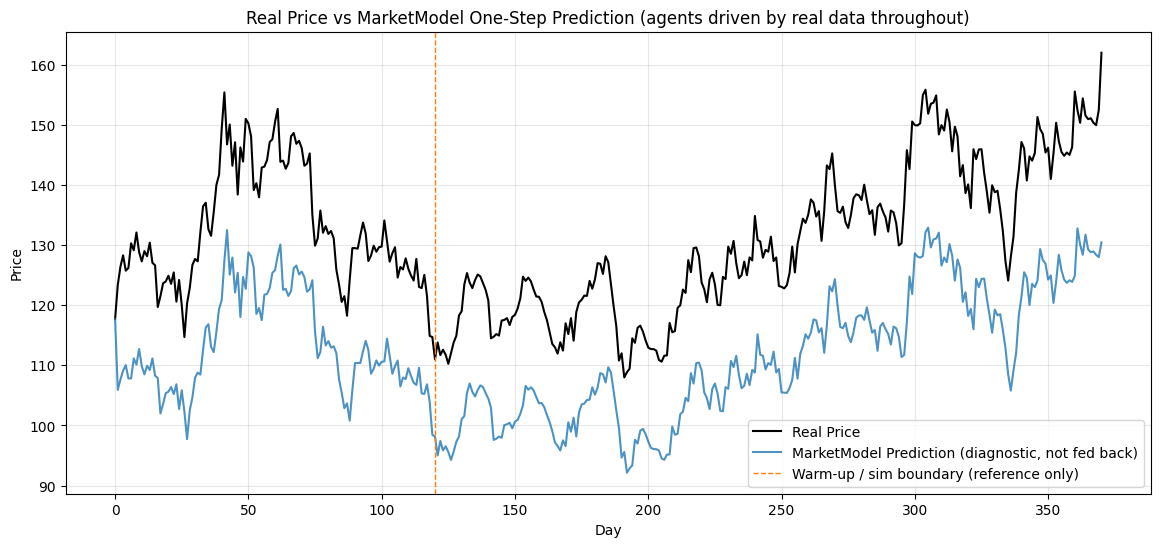

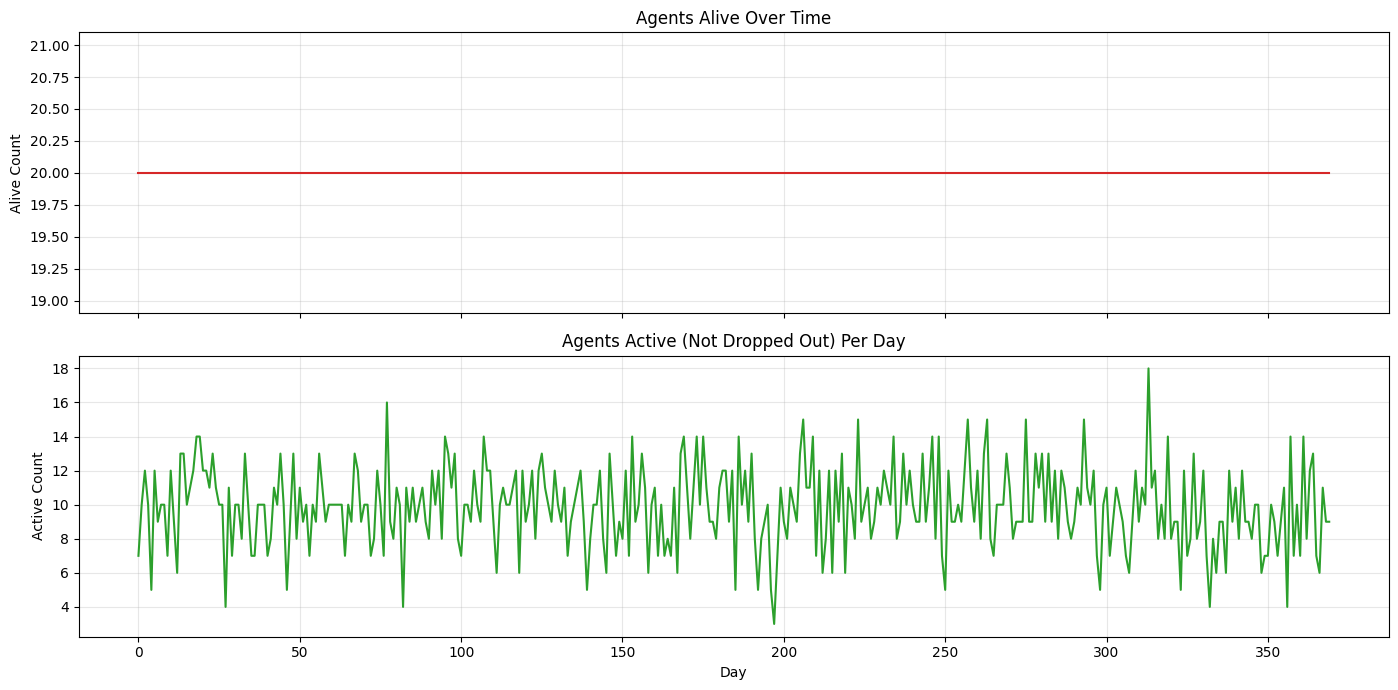

Agents that died: 0 / 20


In [75]:
# ============================================================
# CELL — run + plot (real price vs MarketModel's one-step-ahead prediction)
# ============================================================

# MARKET_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "market_model.pt")

market_model = MarketModel()
market_model.load_state_dict(torch.load(MARKET_MODEL_PATH))
market_model.eval()

result = run_simulation(DATA_PATH, market_model, population, sim_days=250, warmup_days=120)

wi = result["warmup_end_index"]

plt.figure(figsize=(14, 6))
plt.plot(result["real_price_history"], label="Real Price", color="black")
plt.plot(result["predicted_price_history"], label="MarketModel Prediction (diagnostic, not fed back)",
         color="tab:blue", alpha=0.8)
plt.axvline(wi, color="tab:orange", linestyle="--", linewidth=1, label="Warm-up / sim boundary (reference only)")
plt.title("Real Price vs MarketModel One-Step Prediction (agents driven by real data throughout)")
plt.xlabel("Day")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(result["alive_counts"], color="tab:red")
axes[0].set_title("Agents Alive Over Time")
axes[0].set_ylabel("Alive Count")
axes[0].grid(alpha=0.3)

axes[1].plot(result["active_counts"], color="tab:green")
axes[1].set_title("Agents Active (Not Dropped Out) Per Day")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Active Count")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

n_dead = sum(not a.alive for a in result["agents"])
print(f"Agents that died: {n_dead} / {len(result['agents'])}")

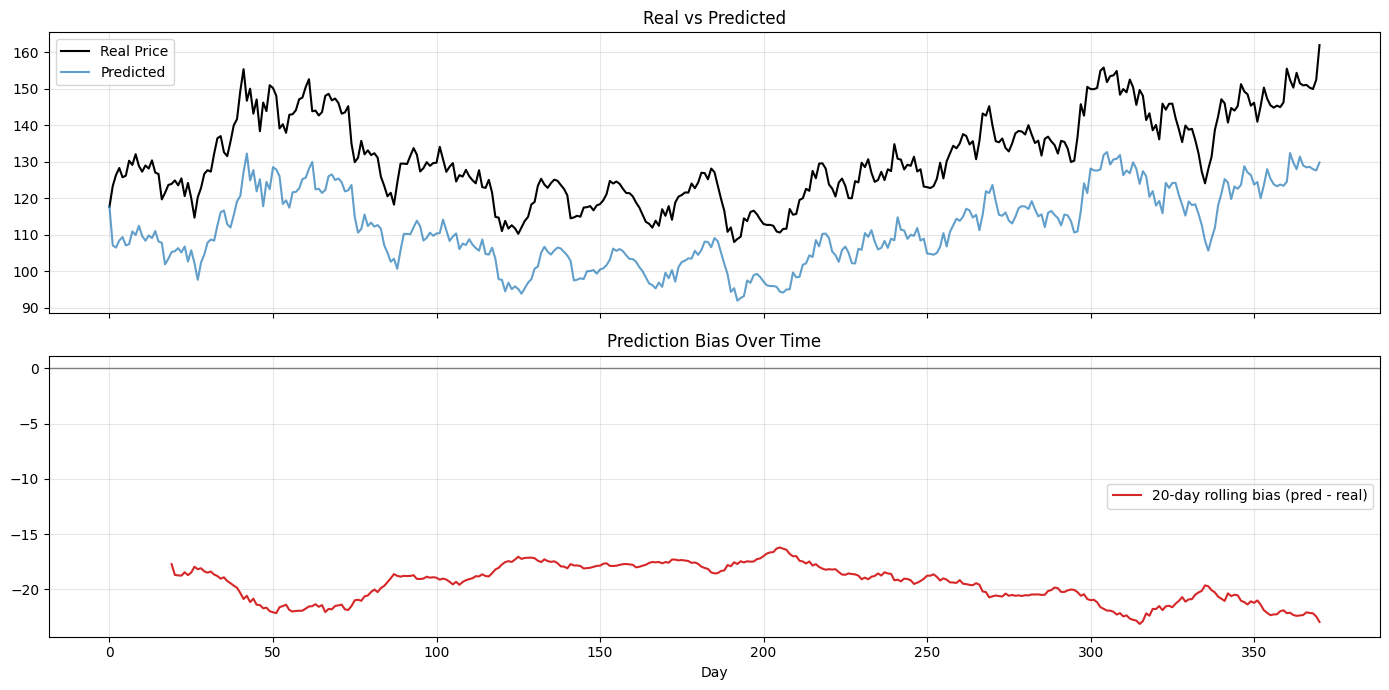

Mean signed error : -19.539983364245607
Mean abs error     : 19.539983364245607


In [66]:
# ============================================================
# CELL — diagnostic: prediction error over time
# ============================================================

real = np.array(result["real_price_history"])
pred = np.array(result["predicted_price_history"])

error = pred - real
rolling_bias = pd.Series(error).rolling(20).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(real, color="black", label="Real Price")
axes[0].plot(pred, color="tab:blue", alpha=0.7, label="Predicted")
axes[0].legend()
axes[0].set_title("Real vs Predicted")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="gray", linewidth=1)
axes[1].plot(rolling_bias, color="tab:red", label="20-day rolling bias (pred - real)")
axes[1].legend()
axes[1].set_title("Prediction Bias Over Time")
axes[1].set_xlabel("Day")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Mean signed error :", error.mean())
print("Mean abs error     :", np.abs(error).mean())